# Proyecto empresa aliada: entregable 2

## 1. Carga los datos:

Carga la tabla consolidada de datos que se realizó en el avance de proyecto con empresa aliada anterior (en Módulo 7: Pandas: Dataframes, lectura y exploración de archivos)  así como también los datos de alguna otra tabla que necesites usar para el EDA o la visualización y no fueron posibles consolidar en un solo archivo.

In [2]:
print("\n" + "="*80)
print("CARGA DE DATAFRAME CONSOLIDADO")
print("="*80)

# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl", 7)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.unicode_minus'] = False  # Para mostrar signos negativos correctamente

# Cargar tabla cvs como DataFrame
df = pd.read_parquet('df_consolidado_final.parquet') # Parquet mantiene tipos de datos originales (DateTime y Category)

# Información del DataFrame
print(f"\n• Dimensiones del DataFrame: {df.shape[0]:,} filas × {df.shape[1]} columnas")

print(f"\n• Periodo (AAAA-MM-DD): {df['DATE'].min().strftime('%Y-%m-%d')} a {df['DATE'].max().strftime('%Y-%m-%d')}")

print(f"\n• Ventas totales: ${df['TOTAL_VALUE_SALES'].sum():,.2f}")

nulos = df.isnull().sum().sum()
if nulos > 0:
    print(f"\n• Valores nulos por columna:")
    nulos_col = df.isnull().sum()
    for col, count in nulos_col[nulos_col > 0].items():
        pct = (count / len(df)) * 100
        print(f"    - {col}: {count:,} ({pct:.2f}%)")
else:
    print(f"\n• No hay valores nulos")

print(f"\n• Estructura del DataFrame:\n")
df.info()

print(f"\n• Estadísticas descriptivas:\n \n{df.describe()}")

print(f"\n• Muestra de 5 filas aleatorias:\n \n{df.sample(5)}")


CARGA DE DATAFRAME CONSOLIDADO

• Dimensiones del DataFrame: 122,002 filas × 46 columnas

• Periodo (AAAA-MM-DD): 2022-01-09 a 2023-07-17

• Ventas totales: $11,042,859.89

• No hay valores nulos

• Estructura del DataFrame:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122002 entries, 0 to 122001
Data columns (total 46 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   ITEM_CODE                    122002 non-null  object        
 1   MANUFACTURER                 122002 non-null  object        
 2   BRAND                        122002 non-null  object        
 3   ITEM_DESCRIPTION             122002 non-null  object        
 4   ID_CATEGORY                  122002 non-null  int64         
 5   CATEGORY                     122002 non-null  object        
 6   SEGMENT                      122002 non-null  object        
 7   FORMAT                       122002 non-null  object        
 8

## 2. Identificar las variables clave para el análisis:

Determina qué variables son más relevantes para responder a las preguntas de negocio.

In [2]:
print("\n" + "="*80)
print("VARIABLES CLAVE IDENTIFICADAS")
print("="*80)

variables_clave = {
    'Ventas': ['TOTAL_VALUE_SALES', 'TOTAL_UNIT_SALES', 'PRICE'],
    'Temporal': ['DATE', 'YEAR', 'MONTH', 'QUARTER', 'MONTH_NAME', 'YEAR_MONTH'],
    'Geográfica': ['REGION', 'REGION_CLEAN', 'REGION_SHORT'],
    'Producto': ['SEGMENT', 'BRAND', 'MANUFACTURER', 'FORMAT', 'SIZE'],
    'Métricas': ['VAR_WEEKLY_AVG', 'VAR_PCT', 'ABOVE_AVG'],
    'Indicadores': ['HIGH_VALUE', 'HIGH_TURNOVER', 'VIP_SALE', 'STAR_PRODUCT']
}

print("\nVariables agrupadas por categoría:")
for categoria, vars in variables_clave.items():
    print(f"\n  {categoria}:")
    for var in vars:
        if var in df.columns:
            print(f"    ✓ {var}")


VARIABLES CLAVE IDENTIFICADAS

Variables agrupadas por categoría:

  Ventas:
    ✓ TOTAL_VALUE_SALES
    ✓ TOTAL_UNIT_SALES
    ✓ PRICE

  Temporal:
    ✓ DATE
    ✓ YEAR
    ✓ MONTH
    ✓ QUARTER
    ✓ MONTH_NAME
    ✓ YEAR_MONTH

  Geográfica:
    ✓ REGION
    ✓ REGION_CLEAN
    ✓ REGION_SHORT

  Producto:
    ✓ SEGMENT
    ✓ BRAND
    ✓ MANUFACTURER
    ✓ FORMAT
    ✓ SIZE

  Métricas:
    ✓ VAR_WEEKLY_AVG
    ✓ VAR_PCT
    ✓ ABOVE_AVG

  Indicadores:
    ✓ HIGH_VALUE
    ✓ HIGH_TURNOVER
    ✓ VIP_SALE
    ✓ STAR_PRODUCT


## 3. Visualizar la distribución de ventas:

Crea gráficos de distribución (histogramas o boxplots) para visualizar la distribución de ventas por diferentes categorías. 
Esto ayudará a identificar patrones de ventas y posibles outliers.

### 3.1 Distribución General de Ventas

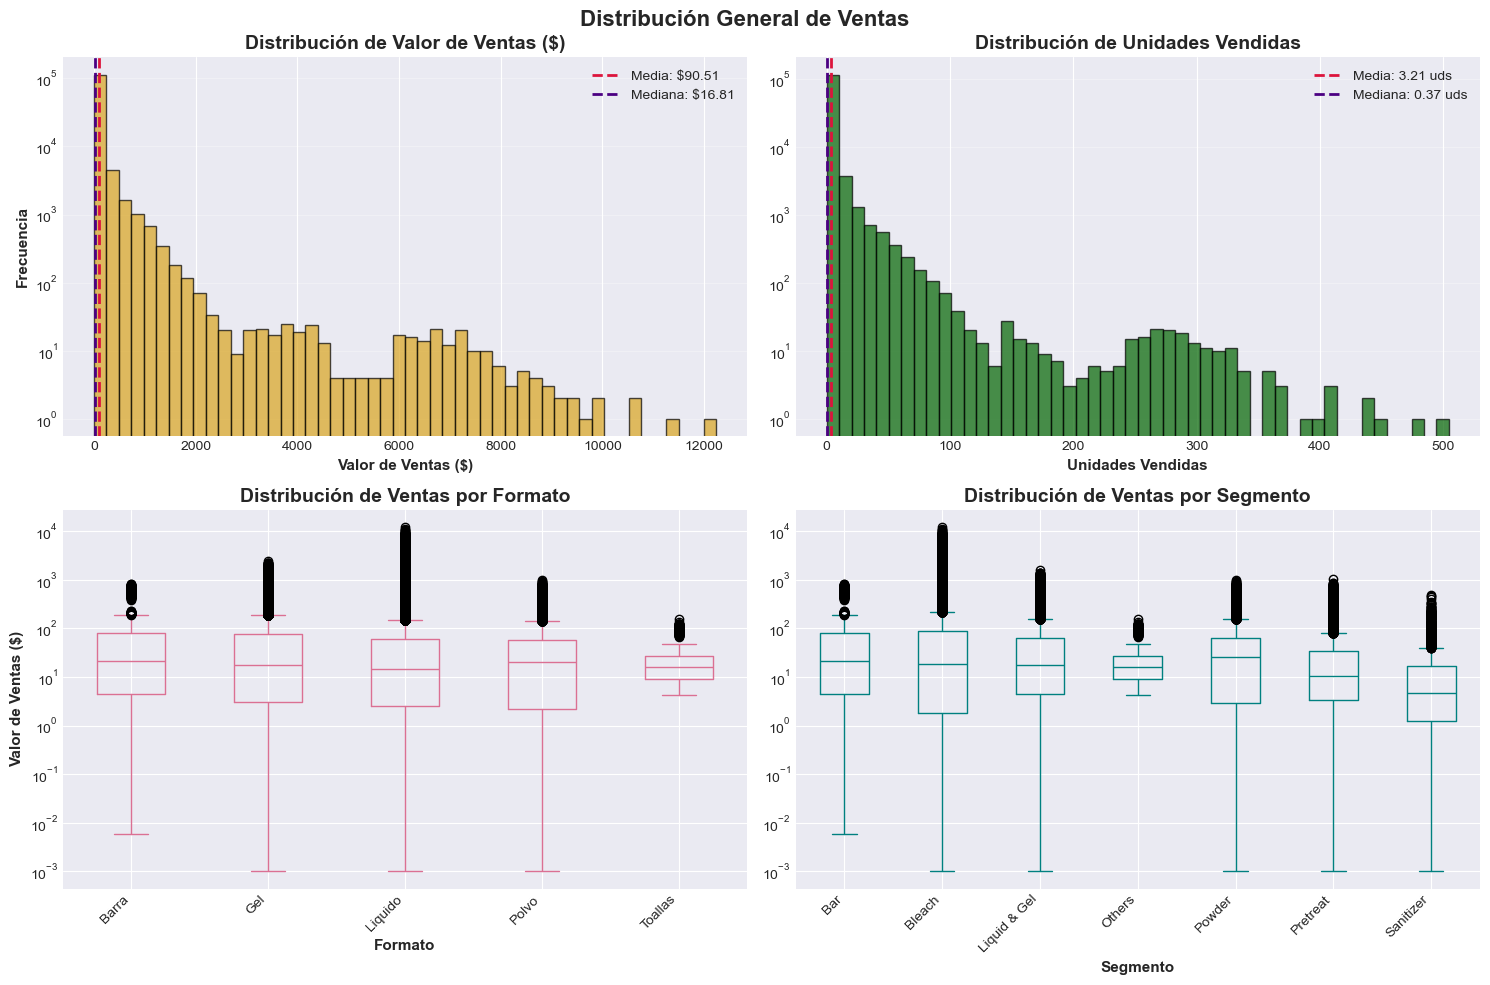


INSIGHTS DEL GRÁFICO 1: Distribución General de Ventas

────────────────────────────────────────────────────────────────────────────────────────────────────
Histograma 1: Distribución de Valor de Ventas ($)
────────────────────────────────────────────────────────────────────────────────────────────────────

• Hallazgos:
    - Distribución con sesgo postivio extremo (right-skewed)
    - Media: $90.51 vs Mediana: $16.81 → la media es ~5.4 veces mayor que la mediana
    - La mayoría de las transacciones son de bajo valor (concentradas entre $0 y $200)
    - Existen transacciones atípicas que alcanzan hasta $12,000+
• Interpretación: 
    - Modelo de negocio de alto volumen y bajo ticket.
    - Una minoría de clientes o transacciones generan ingresos desproporcionadamente altos.


────────────────────────────────────────────────────────────────────────────────────────────────────
Histograma 2: Distribución de Unidades Vendidas
──────────────────────────────────────────────────────────────

In [185]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 1: Distribución General de Ventas
# ══════════════════════════════════════════════════════════════

# Crear Gráficos
fig, axes = plt.subplots(2, 2, figsize=(15, 10)) # Crea una cuadrícula de 2 filas × 2 columnas. Tamaño total: 15 pulgadas ancho × 10 alto

# ──────────────────────────────────────────────────────────────
# HISTOGRAMA 1: Total Value Sales
# ──────────────────────────────────────────────────────────────
axes[0, 0].hist(df['TOTAL_VALUE_SALES'], bins=50, edgecolor='black', alpha=0.7, color='goldenrod')
media = df['TOTAL_VALUE_SALES'].mean()
mediana = df['TOTAL_VALUE_SALES'].median()
axes[0, 0].axvline(media, color='crimson', linestyle='--', linewidth=2, label=f'Media: ${media:.2f}')
axes[0, 0].axvline(mediana, color='indigo', linestyle='--', linewidth=2, label=f'Mediana: ${mediana:.2f}')
axes[0, 0].set_yscale('log') # Escala logarítimica para visualizar todas las barras
axes[0, 0].set_title('Distribución de Valor de Ventas ($)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Valor de Ventas ($)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frecuencia', fontsize=11, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)


# ──────────────────────────────────────────────────────────────
# HISTOGRAMA 2: Total Unit Sales
# ──────────────────────────────────────────────────────────────
axes[0, 1].hist(df['TOTAL_UNIT_SALES'], bins=50, edgecolor='black', alpha=0.7, color='darkgreen')
axes[0, 1].axvline(df['TOTAL_UNIT_SALES'].mean(), color='crimson', linestyle='--', linewidth=2, 
                   label=f"Media: {df['TOTAL_UNIT_SALES'].mean():.2f} uds")
axes[0, 1].axvline(df['TOTAL_UNIT_SALES'].median(), color='indigo', linestyle='--', linewidth=2, 
                   label=f"Mediana: {df['TOTAL_UNIT_SALES'].median():.2f} uds")
axes[0, 1].set_yscale('log') # Escala logarítimica para visualizar todas las barras
axes[0, 1].set_title('Distribución de Unidades Vendidas', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Unidades Vendidas', fontsize=11, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)


# ──────────────────────────────────────────────────────────────
# BOXPLOT 1: Ventas por Formato
# ──────────────────────────────────────────────────────────────
df.boxplot(column='TOTAL_VALUE_SALES', by='FORMAT', ax=axes[1, 0], color='palevioletred')
plt.sca(axes[1, 0])
plt.title('')
axes[1, 0].set_title('Distribución de Ventas por Formato', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Formato', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Valor de Ventas ($)', fontsize=11, fontweight='bold')
axes[1, 0].set_yscale('log') # Usar escala logarítmica para visualizar cajas a pesar de outliers
plt.xticks(rotation=45, ha='right')


# ──────────────────────────────────────────────────────────────
# BOXPLOT 2: Ventas por Segmento
# ──────────────────────────────────────────────────────────────
df.boxplot(column='TOTAL_VALUE_SALES', by='SEGMENT', ax=axes[1, 1], color='teal')
axes[1, 1].set_title('Distribución de Ventas por Segmento', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Segmento', fontsize=11, fontweight='bold')
axes[1, 1].set_yscale('log') # Usar escala logarítmica para visualizar cajas a pesar de outliers
plt.sca(axes[1, 1])
plt.xticks(rotation=45, ha='right')


# Guardar y mostrar figura
plt.tight_layout()
fig.suptitle('Distribución General de Ventas', fontsize=16, fontweight='bold') # Título de toda la figura
plt.savefig('01_distribucion_ventas.png', dpi=300, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════
# INSIGHTS DEL GRÁFICO 1: Distribución General de Ventas
# ══════════════════════════════════════════════════════════════

print("\n" + "="*100)
print('INSIGHTS DEL GRÁFICO 1: Distribución General de Ventas')
print("="*100)

# ──────────────────────────────────────────────────────────────
# Resumen de Histograma 1: Total Value Sales
# ──────────────────────────────────────────────────────────────
print("\n" + "─"*100)
print('Histograma 1: Distribución de Valor de Ventas ($)')
print("─"*100)
print(f"""
• Hallazgos:
    - Distribución con sesgo postivio extremo (right-skewed)
    - Media: $90.51 vs Mediana: $16.81 → la media es ~5.4 veces mayor que la mediana
    - La mayoría de las transacciones son de bajo valor (concentradas entre $0 y $200)
    - Existen transacciones atípicas que alcanzan hasta $12,000+
• Interpretación: 
    - Modelo de negocio de alto volumen y bajo ticket.
    - Una minoría de clientes o transacciones generan ingresos desproporcionadamente altos.
""")


# ──────────────────────────────────────────────────────────────
# Resumen de Histograma 2: Total Unit Sales
# ──────────────────────────────────────────────────────────────
print("\n" + "─"*100)
print('Histograma 2: Distribución de Unidades Vendidas')
print("─"*100)
print(f"""
• Hallazgos:
    - Media: 3.21 uds vs Mediana: 0.37 uds → la media es ~8.7 veces la mediana.
    - La mediana de 0.37 unidades indica que más del 50% de los registros tienen menos de 1 unidad vendida.
• Interpretación:    
    - Volumen de unidades muy bajo por transacción.
    - Hay pocas transacciones o clientes de alto volumen. 
    - Los valores fraccionarios (< 1 unidad) pueden indicar que los datos están agregados por peso, volumen o porciones, como fracciones de paquetes o productos a granel. 
""")


# ──────────────────────────────────────────────────────────────
# Resumen de Boxplot 1: Ventas por Formato
# ──────────────────────────────────────────────────────────────
print("\n" + "─"*100)
print('Boxplot 1: Distribución de Ventas por Formato')
print("─"*100)
print(f"""
• Hallazgos:
    - Líquido → mediana y outliers más altos
    - Gel → segunda posición, con outliers hasta ~$3,000+
    - Barra → mediana baja
    - Polvo → valores moderados
    - Toallas → rango más compacto y valores más bajos
• Interpretación:  
    - Líquido es el formato genera las transacciones de mayor valor y mayor dispersión, lo que indica que tiene tanto productos premium como básicos.
    - Gel es un segundo motor importante de ingresos.
    - Barra, Polvo y Toallas son formatos de ticket bajo y más predecibles (menor variabilidad).
    - Los outliers extremos en Líquido sugieren compras institucionales o al por mayor en este formato.
""")

# ──────────────────────────────────────────────────────────────
# Resumen de Boxplot 2: Ventas por Segmento
# ──────────────────────────────────────────────────────────────
print("\n" + "─"*100)
print('Boxplot 2: Distribución de Ventas por Segmento')
print("─"*100)
print(f"""
• Hallazgos:
    - Liquid & Gel → mayor mediana y dispersión, outliers más extremos (~$10,000+)
    - Bar → outliers altos (~$1,000), pero mediana moderada
    - Bleach → mediana relativamente alta, distribución amplia
    - Pretreat → mediana intermedia, algunos outliers notables
    - Powder → distribución moderada
    - Sanitizar → distribución compacta, valores más bajos
    - Others → mediana más baja, rango compacto
• Interpretación:  
    - Liquid & Gel es el segmento más rentable por transacción.
    - Bleach es producto con demanda constante, tiene un comportamiento estable con buena mediana.
    - Sanitizer y Others son segmentos de bajo valor unitario que probablemente funcionan como complementarios.
    - Hay valores cercanos a $0.001 en varios segmentos (visible en escala log), lo que sugiere registros con errores o transacciones simbólicas que deben investigarse.
""")

### 3.2 Ventas por Segmento

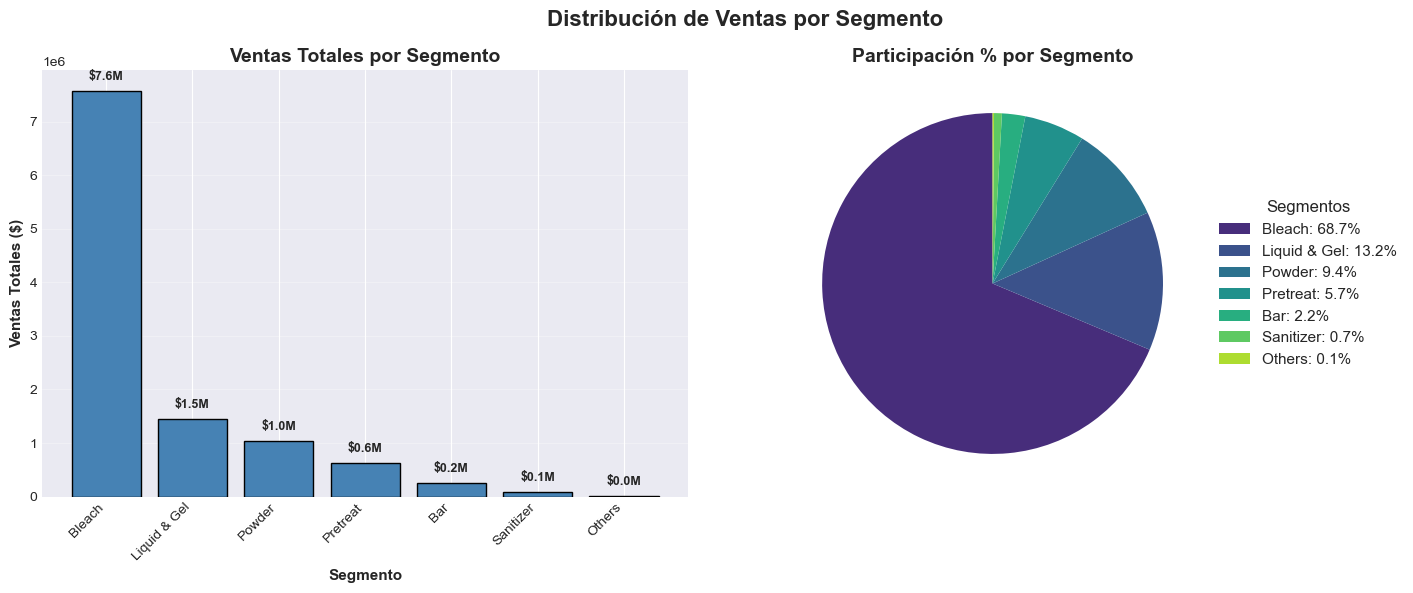


INSIGHTS DEL GRÁFICO 2: Distribución de Ventas por Segmento

────────────────────────────────────────────────────────────────────────────────────────────────────
Gráfico de Barras: Ventas Totales por Segmento
────────────────────────────────────────────────────────────────────────────────────────────────────

• Hallazgos:
    - Bleach domina con $7.6M en ventas totales.
    - Liquid & Gel ocupa un lejano segundo lugar con $1.5M (~5 veces menor que Bleach).
    - Powder en tercer lugar con $1.0M
    - Pretreat aporta $0.6M, siendo el último segmento con volumen relevante.
    - Bar ($0.2M), Sanitizer ($0.1M) y Others ($0.0M) representan contribuciones marginales.
    - La caída entre el 1er y 2do segmento es abrupta: de $7.6M a $1.5M (una reducción del ~80%).
• Interpretación:
    - El negocio tiene una dependencia crítica de un solo segmento (Bleach).
    - Existe una estructura de "cabeza larga y cola corta" → un segmento gigante seguido de varios pequeños.
    - Los últimos 3 segmen

In [187]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 2: Distribución de Ventas por Segmento
# ══════════════════════════════════════════════════════════════

# Agrupar ventas totales por segmento 
ventas_segmento = df.groupby('SEGMENT')['TOTAL_VALUE_SALES'].agg(['sum', 'count', 'mean']).sort_values('sum', ascending=False) # Calcula suma, conteo y media
ventas_segmento['percentage'] = (ventas_segmento['sum'] / ventas_segmento['sum'].sum()) * 100 # Nueva métrica que calcula qué % representa cada segmento del total

# Crear los gráficos
fig, axes = plt.subplots(1, 2, figsize=(15, 6)) # 1 fila, 2 columnas
fig.suptitle('Distribución de Ventas por Segmento', fontsize=16, fontweight='bold')


# ──────────────────────────────────────────────────────────────
# BARRA VERTICALES: Ventas Totales por Segmento
# ──────────────────────────────────────────────────────────────
axes[0].bar(range(len(ventas_segmento)), ventas_segmento['sum'], color='steelblue', edgecolor='black') # range() porque .bar() necesita posiciones numéricas en el eje x
axes[0].set_xticks(range(len(ventas_segmento))) # Define dónde poner las etiquetas (posiciones 0, 1, 2...)
axes[0].set_xticklabels(ventas_segmento.index, rotation=45, ha='right') # Define qué texto poner (Bleach, Powder...)
axes[0].set_title('Ventas Totales por Segmento', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Segmento', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Ventas Totales ($)', fontsize=11, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Añadir etiquetas con valores arriba de cada barra
for i, v in enumerate(ventas_segmento['sum']):
    axes[0].text(i, v + ventas_segmento['sum'].max()*0.02, f'${v/1e6:.1f}M', 
                 ha='center', va='bottom', fontsize=9, fontweight='bold')


# ──────────────────────────────────────────────────────────────
# PIE: Participación % por Segmento
# ──────────────────────────────────────────────────────────────
axes[1].set_title('Participación % por Segmento', fontsize=14, fontweight='bold')
colors = sns.color_palette('viridis', len(ventas_segmento))

wedges, texts = axes[1].pie(
    ventas_segmento['sum'], 
    autopct=None, # Sin porcentaje en el círculo porque no caben todos sin empalmarse
    startangle=90, 
    colors=colors
)
# Leyenda con porcentajes
legend_labels = [
    f'{segment}: {pct:.1f}%' 
    for segment, pct in zip(ventas_segmento.index, ventas_segmento['percentage'])
]
axes[1].legend(
    legend_labels, # Labels con porcentajes
    title="Segmentos",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1), # Posición a la derecha
    fontsize=11,
    title_fontsize=12,
)


# Guardar y mostrar figura
plt.tight_layout()
plt.savefig('02_ventas_por_segmento.png', dpi=300, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════
# INSIGHTS DEL GRÁFICO 1: Distribución de Ventas por Segmento
# ══════════════════════════════════════════════════════════════

print("\n" + "="*100)
print('INSIGHTS DEL GRÁFICO 2: Distribución de Ventas por Segmento')
print("="*100)

# ──────────────────────────────────────────────────────────────
# Resumen de Barra Verticales: Ventas Totales por Segmento
# ──────────────────────────────────────────────────────────────
print("\n" + "─"*100)
print('Gráfico de Barras: Ventas Totales por Segmento')
print("─"*100)
print(f"""
• Hallazgos:
    - Bleach domina con $7.6M en ventas totales.
    - Liquid & Gel ocupa un lejano segundo lugar con $1.5M (~5 veces menor que Bleach).
    - Powder en tercer lugar con $1.0M
    - Pretreat aporta $0.6M, siendo el último segmento con volumen relevante.
    - Bar ($0.2M), Sanitizer ($0.1M) y Others ($0.0M) representan contribuciones marginales.
    - La caída entre el 1er y 2do segmento es abrupta: de $7.6M a $1.5M (una reducción del ~80%).
• Interpretación:
    - El negocio tiene una dependencia crítica de un solo segmento (Bleach).
    - Existe una estructura de "cabeza larga y cola corta" → un segmento gigante seguido de varios pequeños.
    - Los últimos 3 segmentos (Bar, Sanitizer, Others) combinados apenas superan $0.3M → representan menos del 4% del líder.
    - Esta concentración implica alto riesgo → cualquier caída en Bleach impactaría significativamente los ingresos totales del negocio.
""")

# ──────────────────────────────────────────────────────────────
# Resumen de Pie: Participación % por Segmento
# ──────────────────────────────────────────────────────────────
print("\n" + "─"*100)
print('Gráfico Circular: Participación % por Segmento')
print("─"*100)
print(f"""
• Hallazgos:
    - Bleach: 68.7% → casi 7 de cada 10 dólares de venta provienen de este segmento.
    - Liquid & Gel: 13.2% → segundo en participación pero lejos del líder.
    - Powder: 9.4% → tercer contribuyente.
    - Top 3 (Bleach + Liquid & Gel + Powder) = 91.3% del total de ventas.
    - Pretreat: 5.7% → participación modesta pero no despreciable.
    - Bar: 2.2%, Sanitizer: 0.7%, Others: 0.1% → participación residual combinada de apenas 3.0%.
• Interpretación:
    - El portafolio está extremadamente concentrado → 3 de 7 segmentos generan el 91.3% de ingresos.
    - Bleach por sí solo (68.7%) supera la regla de Pareto (80/20) → un solo segmento genera más de dos tercios.
    - Los 4 segmentos inferiores (Pretreat, Bar, Sanitizer, Others) combinados suman apenas 8.7% → su impacto individual en el negocio es limitado.
""")

### 3.3 Ventas por Marca

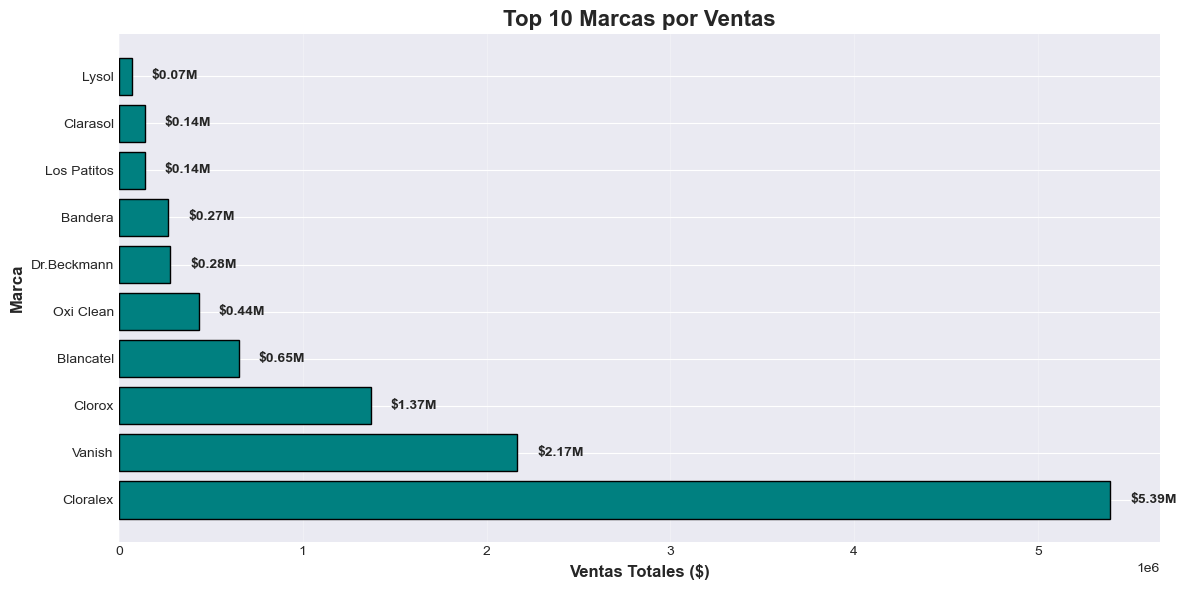


INSIGHTS DEL GRÁFICO 3: Top 10 Marcas por Ventas

• Total de Ventas por Marca del Top 10:
   1. Cloralex    : $5,393,618.51 (48.8%)
   2. Vanish      : $2,168,289.52 (19.6%)
   3. Clorox      : $1,371,751.72 (12.4%)
   4. Blancatel   : $  652,484.02 (5.9%)
   5. Oxi Clean   : $  436,970.72 (4.0%)
   6. Dr.Beckmann : $  279,719.23 (2.5%)
   7. Bandera     : $  269,936.90 (2.4%)
   8. Los Patitos : $  142,745.66 (1.3%)
   9. Clarasol    : $  141,012.17 (1.3%)
  10. Lysol       : $   70,557.35 (0.6%)

• Hallazgos:
    - Cloralex es la marca dominante con $5.39M (48.8% del total):
       Casi 1 de cada 2 dólares vendidos pertenece a Cloralex.
       Vende 2.5 veces más que la segunda marca (Vanish).
    - Top 3 (Cloralex + Vanish + Clorox) concentran el 80.8% de las ventas totales.
    - Vanish y Clorox juntas representan el 32% pero son menos de la mitad de Cloralex.
    - La 4a y 5a marca, Blancatel y Oxi Clean, combinadas suman ~10% del total.
    - Las marcas del puesto 6 al 10 (Dr.Be

In [189]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 3: Top 10 Marcas por Ventas
# ══════════════════════════════════════════════════════════════

# Top 10 marcas
ventas_marca = df.groupby('BRAND')['TOTAL_VALUE_SALES'].sum().sort_values(ascending=False).head(10) # Agrupa ventas por marca


# ──────────────────────────────────────────────────────────────
# BARRAS HORIZONTALES: Top 10 Marcas por Ventas
# ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(ventas_marca)), ventas_marca.values, color='teal', edgecolor='black')
ax.set_yticks(range(len(ventas_marca)))
ax.set_yticklabels(ventas_marca.index)
ax.set_title('Top 10 Marcas por Ventas', fontsize=16, fontweight='bold')
ax.set_xlabel('Ventas Totales ($)', fontsize=12, fontweight='bold')
ax.set_ylabel('Marca', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Añadir valor en millones al final de cada barra
for i, v in enumerate(ventas_marca.values):
    ax.text(v + ventas_marca.max()*0.02, i, f'${v/1e6:.2f}M', 
            va='center', fontsize=10, fontweight='bold')


# Guardar y mostrar figura
plt.tight_layout()
plt.savefig('03_ventas_por_marca.png', dpi=300, bbox_inches='tight')
plt.show()



# ══════════════════════════════════════════════════════════════
# INSIGHTS DEL GRÁFICO 3: Top 10 Marcas por Ventas
# ══════════════════════════════════════════════════════════════

print("\n" + "="*100)
print('INSIGHTS DEL GRÁFICO 3: Top 10 Marcas por Ventas')
print("="*100 + "\n")

# ──────────────────────────────────────────────────────────────
# Resumen de Barras Horizontales: Top 10 Marcas por Ventas
# ──────────────────────────────────────────────────────────────
print('• Total de Ventas por Marca del Top 10:')
for i, (marca, ventas) in enumerate(ventas_marca.items(), 1):
    pct = (ventas / df['TOTAL_VALUE_SALES'].sum()) * 100
    print(f"  {i:2}. {marca:11} : ${ventas:>12,.2f} ({pct:>2.1f}%)")

print(f"""
• Hallazgos:
    - Cloralex es la marca dominante con $5.39M (48.8% del total):
       Casi 1 de cada 2 dólares vendidos pertenece a Cloralex.
       Vende 2.5 veces más que la segunda marca (Vanish).
    - Top 3 (Cloralex + Vanish + Clorox) concentran el 80.8% de las ventas totales.
    - Vanish y Clorox juntas representan el 32% pero son menos de la mitad de Cloralex.
    - La 4a y 5a marca, Blancatel y Oxi Clean, combinadas suman ~10% del total.
    - Las marcas del puesto 6 al 10 (Dr.Beckmann, Bandera, Los Patitos, Clarasol, Lysol) combinadas suman apenas $0.90M (~8.1%).
    - La caída es exponencial: Cloralex ($5.39M) → Lysol ($0.07M), una diferencia de 76x.

• Interpretación:
    - El mercado está altamente concentrado en una sola marca (Cloralex).
    - Clorox, competidor directo de Cloralex en blanqueadores, tiene solo 1/4 de su cuota.
    - Las marcas Blancatel, Bandera, Los Patitos y Clarasol probablemente compiten por el nicho regional de bajo costo.
    - Marcas internacionales Dr.Beckmann, Oxi Clean, Lysol tienen participación baja, lo que sugiere que el mercado es muy sensible al precio.
""")

## 4. Analizar la tendencia de ventas en el tiempo:

Genera gráficos de líneas que muestren las tendencias de ventas a lo largo del tiempo. Filtra las ventas por diferentes productos, regiones o segmentos para analizar cómo han cambiado las ventas a lo largo del tiempo.

### 4.1 Evolución Mensual

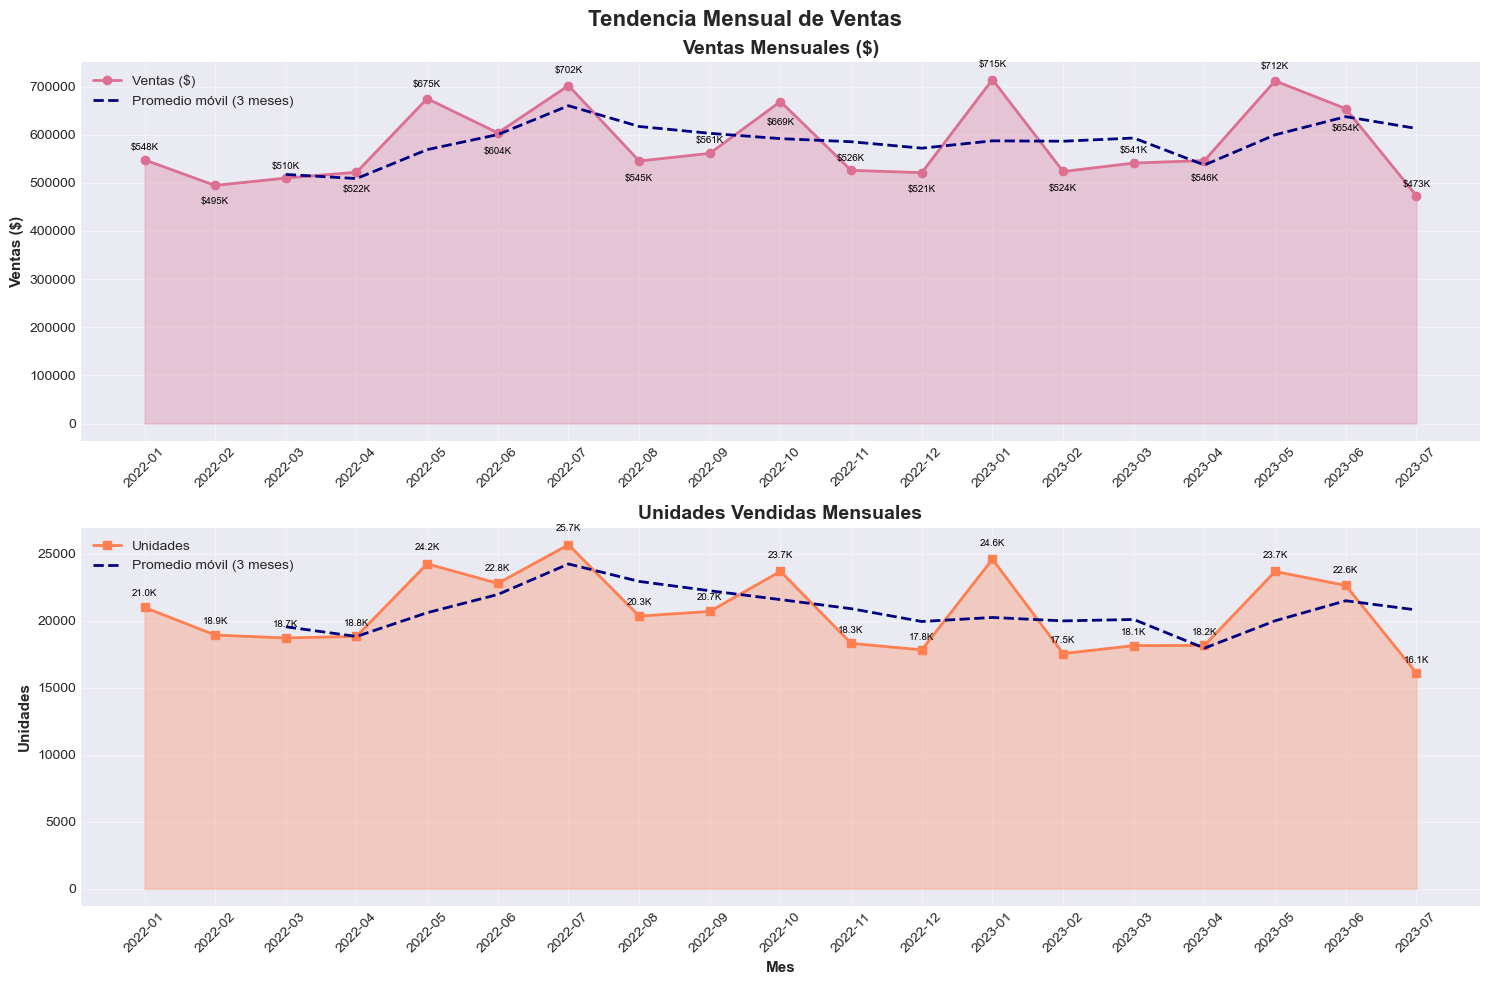


INSIGHTS DEL GRÁFICO 4: Tendencia Mensual de Ventas

• Periodo analizado: January 2022 a July 2023

────────────────────────────────────────────────────────────────────────────────────────────────────
Diagrama Lineal 1: Ventas Mensuales ($)
────────────────────────────────────────────────────────────────────────────────────────────────────

• Hallazgos:
    - Rango de ventas mensuales: entre ~$490K (meses valle) y ~$700K (meses pico)
    - Picos de ventas identificados:
        Mayo-Julio 2022: escalada hasta ~$695K → pico máximo del periodo
        Octubre 2022: repunte a ~$650K
        Diciembre 2022 - Enero 2023: ~$660K → temporada navideña/inicio de año
        Mayo-Junio 2023: ~$700K → nuevo pico, supera al del año anterior
    - Valles de ventas:
       - Febrero 2022: ~$490K → mes más bajo de 2022
       - Febrero-Marzo 2023: ~$520K → patrón: febrero es consistentemente bajo
    - Julio 2023: caída brusca a ~$470K → MES INCOMPLETO, no es una caída real
    - El promedio móvil d

In [191]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 4: Tendencia Mensual de Ventas
# ══════════════════════════════════════════════════════════════

# Agrupar ventas y unidades por año-mes
ventas_mensuales = df.groupby('YEAR_MONTH').agg({
    'TOTAL_VALUE_SALES': 'sum', # Sumar ventas en $
    'TOTAL_UNIT_SALES': 'sum' # Sumar unidades
}).sort_index() # Ordena por el índice YEAR_MONTH cronológicamente

# Crear los gráficos
fig, axes = plt.subplots(2, 1, figsize=(15, 10)) # 2 filas, 1 columna
fig.suptitle('Tendencia Mensual de Ventas', fontsize=16, fontweight='bold')


# ──────────────────────────────────────────────────────────────
# DIAGRAMA LINEAL 1: Ventas Mensuales ($)
# ──────────────────────────────────────────────────────────────
axes[0].plot(ventas_mensuales.index, ventas_mensuales['TOTAL_VALUE_SALES'], 
             marker='o', linewidth=2, markersize=6, color='palevioletred', label='Ventas ($)')
axes[0].fill_between(ventas_mensuales.index, ventas_mensuales['TOTAL_VALUE_SALES'], alpha=0.3, color='palevioletred') # Rellena el área bajo la línea

# Promedio móvil (Moving Average) con ventana de 3 meses para facilitar visualización de tendencia
if len(ventas_mensuales) >= 3:
    ma_3 = ventas_mensuales['TOTAL_VALUE_SALES'].rolling(window=3).mean()
    axes[0].plot(ma_3.index, ma_3.values, '--', linewidth=2, 
                 color='navy', label='Promedio móvil (3 meses)')

# Posición de etiquetas
for i, (fecha, valor) in enumerate(ventas_mensuales['TOTAL_VALUE_SALES'].items()):
    # Alternar arriba/abajo
    if i % 2 == 0:
        va = 'bottom'
        offset = valor * 0.03 # 3% arriba del valor
    else:
        va = 'top'
        offset = -valor * 0.05 # 5% arriba del valor
    
    axes[0].text(i, # posición X (índice del mes)
                 valor + offset, # posición Y (valor + distancia)
                 f'${valor/1e3:.0f}K', # valores en miles
                 ha='center', 
                 va=va,
                 fontsize=7,
                 color='black')
axes[0].set_title('Ventas Mensuales ($)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Ventas ($)', fontsize=11, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.4)
axes[0].tick_params(axis='x', rotation=45)
    

# ──────────────────────────────────────────────────────────────
# DIAGRAMA LINEAL 2: Unidades Mensuales Vendidas
# ──────────────────────────────────────────────────────────────
axes[1].plot(ventas_mensuales.index, ventas_mensuales['TOTAL_UNIT_SALES'], 
             marker='s', linewidth=2, markersize=6, color='coral', label='Unidades')
axes[1].fill_between(ventas_mensuales.index, ventas_mensuales['TOTAL_UNIT_SALES'], alpha=0.3, color='coral')

# Promedio móvil (Moving Average) con ventana de 3 meses para facilitar visualización de tendencia
if len(ventas_mensuales) >= 3:
    ma_3 = ventas_mensuales['TOTAL_UNIT_SALES'].rolling(window=3).mean()
    axes[1].plot(ma_3.index, ma_3.values, '--', linewidth=2, 
                 color='navy', label='Promedio móvil (3 meses)')

# Posición de etiquetas
for i, (fecha, valor) in enumerate(ventas_mensuales['TOTAL_UNIT_SALES'].items()):
    axes[1].text(i, # posición X (índice del mes)
                 valor + (valor * 0.035), # posición Y (valor + distancia)
                 f'{valor/1e3:.1f}K', # valores en miles
                 ha='center', 
                 va='bottom',
                 fontsize=7,
                 color='black')
axes[1].set_title('Unidades Vendidas Mensuales', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mes', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Unidades', fontsize=11, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.4)
axes[1].tick_params(axis='x', rotation=45)


# Guardar y mostrar figura
plt.tight_layout()
plt.savefig('04_tendencia_temporal.png', dpi=300, bbox_inches='tight')
plt.show()



# ══════════════════════════════════════════════════════════════
# INSIGHTS DEL GRÁFICO 4: Tendencia Mensual de Ventas
# ══════════════════════════════════════════════════════════════

print("\n" + "="*100)
print('INSIGHTS DEL GRÁFICO 4: Tendencia Mensual de Ventas')
print("="*100 + "\n")

print(f"• Periodo analizado: {df['DATE'].min().strftime('%B %Y')} a {df['DATE'].max().strftime('%B %Y')}")


# ──────────────────────────────────────────────────────────────
# Resumen de Diagrama Lineal 1: Ventas Mensuales ($)
# ──────────────────────────────────────────────────────────────
print("\n" + "─"*100)
print('Diagrama Lineal 1: Ventas Mensuales ($)')
print("─"*100)

print(f"""
• Hallazgos:
    - Rango de ventas mensuales: entre ~$490K (meses valle) y ~$700K (meses pico)
    - Picos de ventas identificados:
        Mayo-Julio 2022: escalada hasta ~$695K → pico máximo del periodo
        Octubre 2022: repunte a ~$650K
        Diciembre 2022 - Enero 2023: ~$660K → temporada navideña/inicio de año
        Mayo-Junio 2023: ~$700K → nuevo pico, supera al del año anterior
    - Valles de ventas:
       - Febrero 2022: ~$490K → mes más bajo de 2022
       - Febrero-Marzo 2023: ~$520K → patrón: febrero es consistentemente bajo
    - Julio 2023: caída brusca a ~$470K → MES INCOMPLETO, no es una caída real
    - El promedio móvil de 3 meses muestra una tendencia ligeramente ASCENDENTE:
       - Inicia alrededor de ~$520K a principios de 2022
       - Se estabiliza en ~$580-630K hacia mediados de 2023
       - Esto indica un crecimiento moderado del negocio año contra año

• Interpretación:
    - Existe un PATRÓN ESTACIONAL claro que se repite:
        Febrero = mes más bajo → post-temporada navideña, cuesta de enero
        Mayo-Julio = meses más fuertes → limpieza de primavera/verano
        Octubre y Diciembre = repuntes secundarios → preparación para fiestas
    - El negocio muestra crecimiento interanual:
        Pico 2022 (~$695K en Jul) < Pico 2023 (~$700K en May) → ligero aumento
    - La volatilidad mensual es moderada (~30% entre pico y valle) → normal para productos de consumo masivo con componente estacional.
""")


# ──────────────────────────────────────────────────────────────
# Resumen de Diagrama Lineal 2: Unidades Vendidas Mensuales
# ──────────────────────────────────────────────────────────────
print("\n" + "─"*100)
print('Diagrama Lineal 2: Unidades Vendidas Mensuales')
print("─"*100)

print(f"""
• Hallazgos:
    - Rango de unidades: entre ~16,000 (valle) y ~26,000 (pico) unidades mensuales
    - Los picos de unidades coinciden con los picos de ventas en $:
        Julio 2022: ~26,000 uds (máximo)
        Mayo 2022, Octubre 2022, Enero 2023, Mayo 2023: ~23,000-24,000 uds
    - Los valles también coinciden:
        Febrero-Abril 2022 y Febrero-Marzo 2023: ~18,000-19,000 uds
    - Julio 2023: ~16,000 uds → refleja mes incompleto
    - La tendencia general de unidades es MÁS PLANA que la de ventas en $

• Interpretación:
    - La correlación entre $ y unidades es alta pero no perfecta.
    - Las ventas en $ crecen ligeramente más que las unidades: 
        esto sugiere un incremento gradual del PRECIO PROMEDIO por unidad (posible efecto inflación o mix de productos más caros).
    - Si las unidades se mantienen estables pero los $ suben, el crecimiento es impulsado por PRECIO, no por VOLUMEN: 
        esto es un riesgo si los consumidores empiezan a migrar hacia opciones más baratas.
""")

### 4.2 Ventas por Trimestre

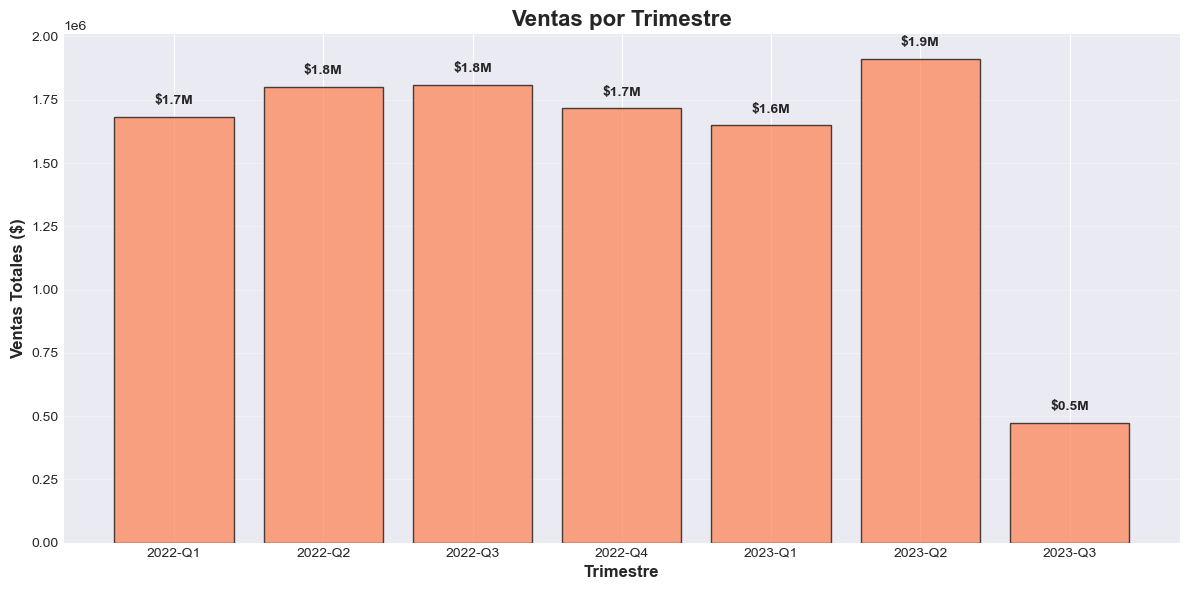


INSIGHTS DEL GRÁFICO 5: Tendencia Trimestral de Ventas

• Ganancias trimestrales:
   2022-Q1: $1,683,028.29
   2022-Q2: $1,800,753.81
   2022-Q3: $1,808,729.57
   2022-Q4: $1,716,107.38
   2023-Q1: $1,648,742.01
   2023-Q2: $1,912,372.21
   2023-Q3: $473,126.62

• Hallazgos:
    - Mejor trimestre: 2023-Q2 con $1.9M → máximo histórico del periodo analizado
    - Trimestre incompleto: 2023-Q3 con $0.5M → solo contiene julio, NO es una caída real
    - Rango de trimestres completos: $1.6M (2023-Q1) a $1.9M (2023-Q2)
       Variación entre el mínimo y máximo completo: ~18%
    - Patrón estacional trimestral:
        Q1 (ene-mar): consistentemente más bajo → $1.7M (2022) y $1.6M (2023)
        Q2 (abr-jun): consistentemente el más fuerte → $1.8M (2022) y $1.9M (2023)
        Q3 (jul-sep): se mantiene fuerte → $1.8M (2022), similar a Q2
        Q4 (oct-dic): ligera caída vs Q2-Q3 → $1.7M (2022)
    - Comparación interanual (trimestres equivalentes):
        Q1: $1.68M (2022) vs $1.65M (2023

In [195]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 5: Tendencia Trimestral de Ventas
# ══════════════════════════════════════════════════════════════

# Agrupar y sumar ventas por trimestre
ventas_trimestre = df.groupby('YEAR_QUARTER')['TOTAL_VALUE_SALES'].sum().sort_index() # Agrupa por trimestre (Q1 a Q4)


# ──────────────────────────────────────────────────────────────
# BARRAS VERTICALES: Ventas por Trimestre
# ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(len(ventas_trimestre)), ventas_trimestre.values, 
       color='coral', edgecolor='black', alpha=0.7)
ax.set_xticks(range(len(ventas_trimestre)))
ax.set_xticklabels(ventas_trimestre.index, ha='center')
ax.set_title('Ventas por Trimestre', fontsize=16, fontweight='bold')
ax.set_xlabel('Trimestre', fontsize=12, fontweight='bold')
ax.set_ylabel('Ventas Totales ($)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Añadir valores a cada barra
for i, v in enumerate(ventas_trimestre.values):
    ax.text(i, v + ventas_trimestre.max()*0.02, f'${v/1e6:.1f}M',  # v/1e6 convierte a millones
            ha='center', va='bottom', fontsize=10, fontweight='bold')


# Guardar y mostrar figura
plt.tight_layout()
plt.savefig('05_ventas_trimestre.png', dpi=300, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════
# INSIGHTS DEL GRÁFICO 5: Tendencia Trimestral de Ventas
# ══════════════════════════════════════════════════════════════

print("\n" + "="*100)
print('INSIGHTS DEL GRÁFICO 5: Tendencia Trimestral de Ventas')
print("="*100 + "\n")

# ──────────────────────────────────────────────────────────────
# Resumen de Barras Verticales: Ventas por Trimestre
# ──────────────────────────────────────────────────────────────
print('• Ganancias trimestrales:')
for trim, ventas in ventas_trimestre.items():
    print(f"   {trim}: ${ventas:,.2f}")

print(f"""
• Hallazgos:
    - Mejor trimestre: 2023-Q2 con $1.9M → máximo histórico del periodo analizado
    - Trimestre incompleto: 2023-Q3 con $0.5M → solo contiene julio, NO es una caída real
    - Rango de trimestres completos: $1.6M (2023-Q1) a $1.9M (2023-Q2)
       Variación entre el mínimo y máximo completo: ~18%
    - Patrón estacional trimestral:
        Q1 (ene-mar): consistentemente más bajo → $1.7M (2022) y $1.6M (2023)
        Q2 (abr-jun): consistentemente el más fuerte → $1.8M (2022) y $1.9M (2023)
        Q3 (jul-sep): se mantiene fuerte → $1.8M (2022), similar a Q2
        Q4 (oct-dic): ligera caída vs Q2-Q3 → $1.7M (2022)
    - Comparación interanual (trimestres equivalentes):
        Q1: $1.68M (2022) vs $1.65M (2023) → caída del -2.0%
        Q2: $1.80M (2022) vs $1.91M (2023) → crecimiento del +6.2%
        El negocio crece en Q2 pero se contrae ligeramente en Q1

• Interpretación:
    - El negocio es estabñe a nivel trimestral, sin grandes fluctuaciones.
    - Q2 es el trimestre estrella: temporada cálida → mayor uso de productos de limpieza/blanqueadores
    - Q1 es el trimestre más débil: cuesta de enero en México → menor actividad de compra
    - El crecimiento interanual es modesto (+6.2% en Q2) pero positivo, 
        lo que indica un negocio maduro en fase de mantenimiento, no de expansión acelerada.
    - La estabilidad trimestral (~$1.7M promedio) facilita la planificación financiera.
""")

### 4.3 Evolución por Segmento

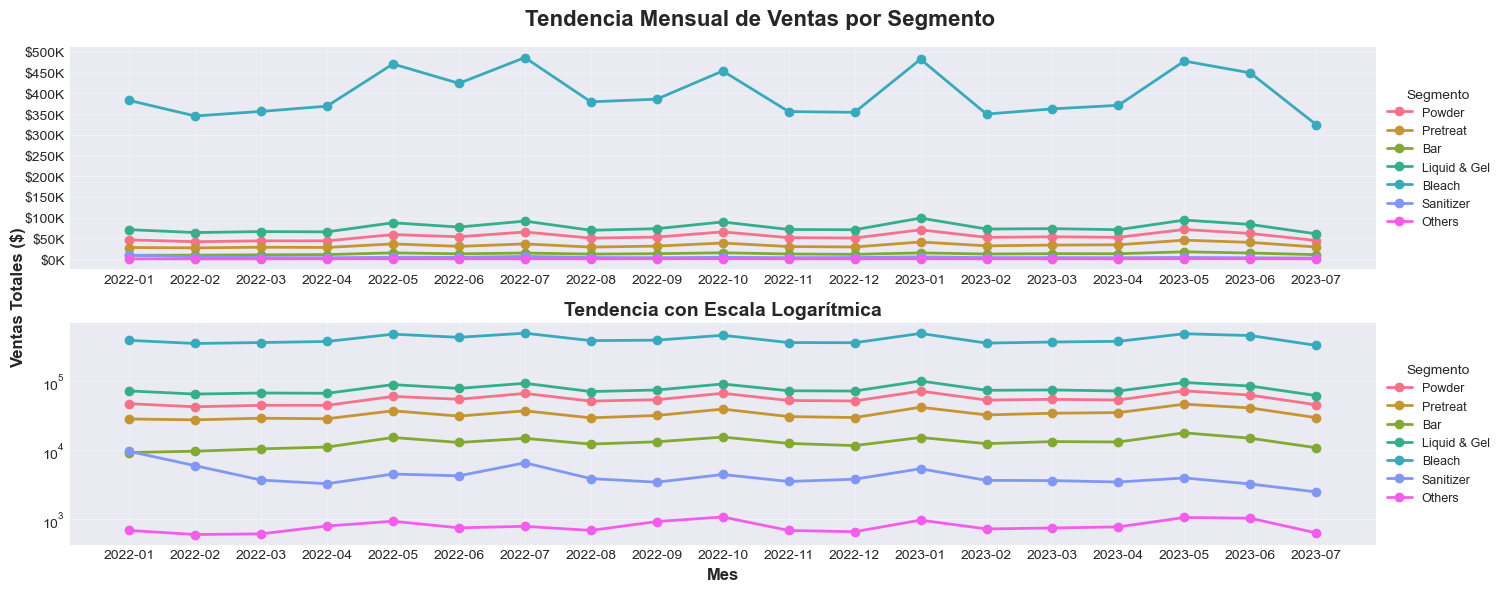


INSIGHTS DEL GRÁFICO 6: Tendencia Mensual de Ventas por Segmento



──────────────────────────────────────────────────────────────────────────────────────────
Tabla Comparativa de Todos los Segmentos
──────────────────────────────────────────────────────────────────────────────────────────

  Segmento    Promedio/Mes   Mes Pico Valor Pico   Mes Valle Valor Valle   CV%
────────────────────────────────────────────────────────────────────────────────
  Bleach        $  403,165    2022-07 $  486,305    2022-02 $  345,315    13.0%
  Liquid & Gel  $   77,396    2023-01 $   99,037    2022-02 $   64,071    13.9%
  Powder        $   55,008    2023-05 $   71,472    2022-02 $   41,952    16.2%
  Pretreat      $   33,489    2023-05 $   45,740    2022-02 $   27,147    16.1%
  Bar           $   12,934    2023-05 $   17,629    2022-01 $    9,150    17.1%
  Sanitizer     $    4,414    2022-01 $    9,505    2023-06 $    3,208    35.6%
  Others        $      801    2022-10 $    1,070    2022-02 $      

In [199]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 6: Tendencia Mensual de Ventas por Segmento
# ══════════════════════════════════════════════════════════════

# Crear los gráficos
fig, axes = plt.subplots(2, 1, figsize=(15, 6)) # 2 filas, 1 columna
fig.suptitle('Tendencia Mensual de Ventas por Segmento', fontsize=16, fontweight='bold')

# Graficar cada segmento por sus ventas mensuales
for segmento in df['SEGMENT'].unique():
    ventas_seg = df[df['SEGMENT'] == segmento].groupby('YEAR_MONTH')['TOTAL_VALUE_SALES'].sum()
    axes[0].plot(ventas_seg.index, ventas_seg.values, marker='o', label=segmento, linewidth=2)
    axes[1].plot(ventas_seg.index, ventas_seg.values, marker='o', label=segmento, linewidth=2)
    
fig.text(0.0001, 0.5, 'Ventas Totales ($)', va='center', rotation='vertical', fontsize=12, fontweight='bold') # Misma descripción para ambos gráficos en eje Y


# ──────────────────────────────────────────────────────────────
# DIAGRAMA LINEAL 1: Tendencia Mensual de Ventas por Segmento
# ──────────────────────────────────────────────────────────────
intervalo = 50_000 # Crear ticks cada $50K
yticks = np.arange(0, 550000, intervalo)
axes[0].set_yticks(yticks)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e3:.0f}K')) # Formatear etiquetas del eje Y
axes[0].legend(title='Segmento', loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
axes[0].grid(True, alpha=0.3)
plt.xticks(ha='center')


# ──────────────────────────────────────────────────────────────
# DIAGRAMA LINEAL 1: Tendencia Mensual de Ventas por Segmento con Escala Logarítmica
# ──────────────────────────────────────────────────────────────
axes[1].set_yscale('log') # Usar escala logarítmica para visualizar todos los segmentos a pesar de Bleach
axes[1].set_title('Tendencia con Escala Logarítmica', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mes', fontsize=12, fontweight='bold')
axes[1].legend(title='Segmento', loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
axes[1].grid(True, alpha=0.3)
plt.xticks(ha='center')


# Guardar y mostrar figura
plt.tight_layout()
plt.savefig('06_tendencia_por_segmento.png', dpi=300, bbox_inches='tight')
plt.show()



# ══════════════════════════════════════════════════════════════
# INSIGHTS DEL GRÁFICO 6: Tendencia Mensual de Ventas por Segmento
# ══════════════════════════════════════════════════════════════

print("\n" + "="*100)
print('INSIGHTS DEL GRÁFICO 6: Tendencia Mensual de Ventas por Segmento')
print("="*100 + "\n")

# ──────────────────────────────────────────────────────────────
# TABLA COMPARATIVA: Todos los Segmentos
# ──────────────────────────────────────────────────────────────
print("\n\n" + "─"*90)
print('Tabla Comparativa de Todos los Segmentos')
print("─"*90)
print(f"\n  {'Segmento':<11} {'Promedio/Mes':>10} {'Mes Pico':>10} {'Valor Pico':>10} {'Mes Valle':>11} {'Valor Valle':>11} {'CV%':>5}")
print("─"*80)

for segmento, datos in resumen_ordenado.items(): # Imprime una fila por segmento con todos sus valores alineados
    print(f"  {segmento:<13} ${datos['promedio']:>9,.0f} {datos['mes_pico']:>10} ${datos['maximo']:>9,.0f} {datos['mes_valle']:>10} ${datos['minimo']:>9,.0f} {datos['cv']:>7.1f}%")

# ──────────────────────────────────────────────────────────────
# TABLA DETALLADA: Rangos, Picos y Valles por Segmento
# ──────────────────────────────────────────────────────────────
print("\n\n" + "─"*90)
print('Resumen Estadístico por Segmento (Ventas Mensuales)')
print("─"*90)

# Calcular métricas por segmento
resumen_segmentos = {}
for segmento in df['SEGMENT'].unique():
    ventas_seg = df[df['SEGMENT'] == segmento].groupby('YEAR_MONTH')['TOTAL_VALUE_SALES'].sum()
    
    # Excluir julio 2023 (mes incompleto) para cálculos justos
    ventas_seg_completos = ventas_seg[ventas_seg.index != '2023-07']
    
    resumen_segmentos[segmento] = {
        'ventas_mensuales': ventas_seg, # Todos los meses incluido julio 2023
        'ventas_completos': ventas_seg_completos, # Solo los 18 meses completos
        'total': ventas_seg_completos.sum(), # Suma de los 18 meses
        'promedio': ventas_seg_completos.mean(), # Promedio mensual
        'mediana': ventas_seg_completos.median(), # Valor central
        'minimo': ventas_seg_completos.min(), # Mes con menos ventas
        'maximo': ventas_seg_completos.max(), # Mes con más ventas
        'mes_pico': ventas_seg_completos.idxmax(), # Nombre del mes con más ventas
        'mes_valle': ventas_seg_completos.idxmin(), # Nombre del mes con menos ventas
        'std': ventas_seg_completos.std(), # Desviación estándar (qué tanto varían los datos)
        'cv': (ventas_seg_completos.std() / ventas_seg_completos.mean()) * 100  # Coeficiente de variación en % → mide qué tan dispersos están los datos relativo a su promedio
    }
    
# Imprimir tabla detallada por segmento
for i, (segmento, datos) in enumerate(resumen_ordenado.items(), 1):
    print(f"\n  {'─'*60}")
    print(f"  {i}. {segmento.upper()}")
    print(f"  {'─'*60}")
    print(f"   Ventas totales (18 meses completos) : ${datos['total']:>12,.2f}")
    print(f"   Promedio mensual                    : ${datos['promedio']:>12,.2f}")
    print(f"   Mediana mensual                     : ${datos['mediana']:>12,.2f}")
    print(f"   Desviación estándar                 : ${datos['std']:>12,.2f}")
    print(f"   Coeficiente de variación            :  {datos['cv']:>10.1f}%")
    print(f"  ")
    print(f"   ✦ MES PICO  : {datos['mes_pico']}   →  ${datos['maximo']:>10,.2f}")
    print(f"   ✦ MES VALLE : {datos['mes_valle']}  →  ${datos['minimo']:>10,.2f}")
    print(f"   ✦ RANGO     : ${datos['minimo']:>10,.2f}  ─  ${datos['maximo']:>10,.2f}  (Δ ${datos['maximo']-datos['minimo']:>10,.2f})") # Rango min al max y su diferencia (delta Δ)
    print(f"   ✦ Variación pico-valle              :  {((datos['maximo']-datos['minimo'])/datos['minimo']*100):>10.1f}%") # Calcula qué porcentaje representa la diferencia respecto al valle


# ──────────────────────────────────────────────────────────────
# ANÁLISIS DE TENDENCIA: Comparación Primer Semestre 2022 vs 2023
# ──────────────────────────────────────────────────────────────
print("\n\n" + "─"*90)
print('Análisis de Tendencia: Primer Semestre 2022 vs 2023 (Ene-Jun)')
print("─"*90)
meses_s1_2022 = ['2022-01', '2022-02', '2022-03', '2022-04', '2022-05', '2022-06'] #  meses del primer semestre 2022
meses_s1_2023 = ['2023-01', '2023-02', '2023-03', '2023-04', '2023-05', '2023-06'] #  meses del primer semestre 2023

print(f"\n  {'Segmento':<13} {'S1 2022':>10} {'S1 2023':>11} {'Cambio $':>11} {'Cambio %':>11} {'Tendencia':>12}")
print("─"*80)
for segmento, datos in resumen_ordenado.items():
    ventas = datos['ventas_mensuales']
    s1_2022 = ventas[ventas.index.isin(meses_s1_2022)].sum() # filra y suma las ventas del semestre 1 2022
    s1_2023 = ventas[ventas.index.isin(meses_s1_2023)].sum() # filra y suma las ventas del semestre 1 2023
    cambio = s1_2023 - s1_2022 # Calcula el cambio absoluto
    cambio_pct = (cambio / s1_2022) * 100 if s1_2022 > 0 else 0 # Calcula el cambio porcentual (si no hay ventas en 2022, no dividir entre 0)
    tendencia = '✓ Crecimiento' if cambio > 0 else '✗ Declive' if cambio < 0 else '→ Estable'
    print(f"  {segmento:<13} ${s1_2022:>10,.0f} ${s1_2023:>10,.0f} ${cambio:>+10,.0f} {cambio_pct:>+9.1f}% {tendencia:>12}")

## 5. Explorar la relación entre diferentes variables:

Utiliza gráficos de dispersión (scatter plots) para investigar relaciones entre variables clave. Esto puede ayudar a identificar correlaciones significativas entre diferentes variables.

### 5.1 Matriz de Correlación

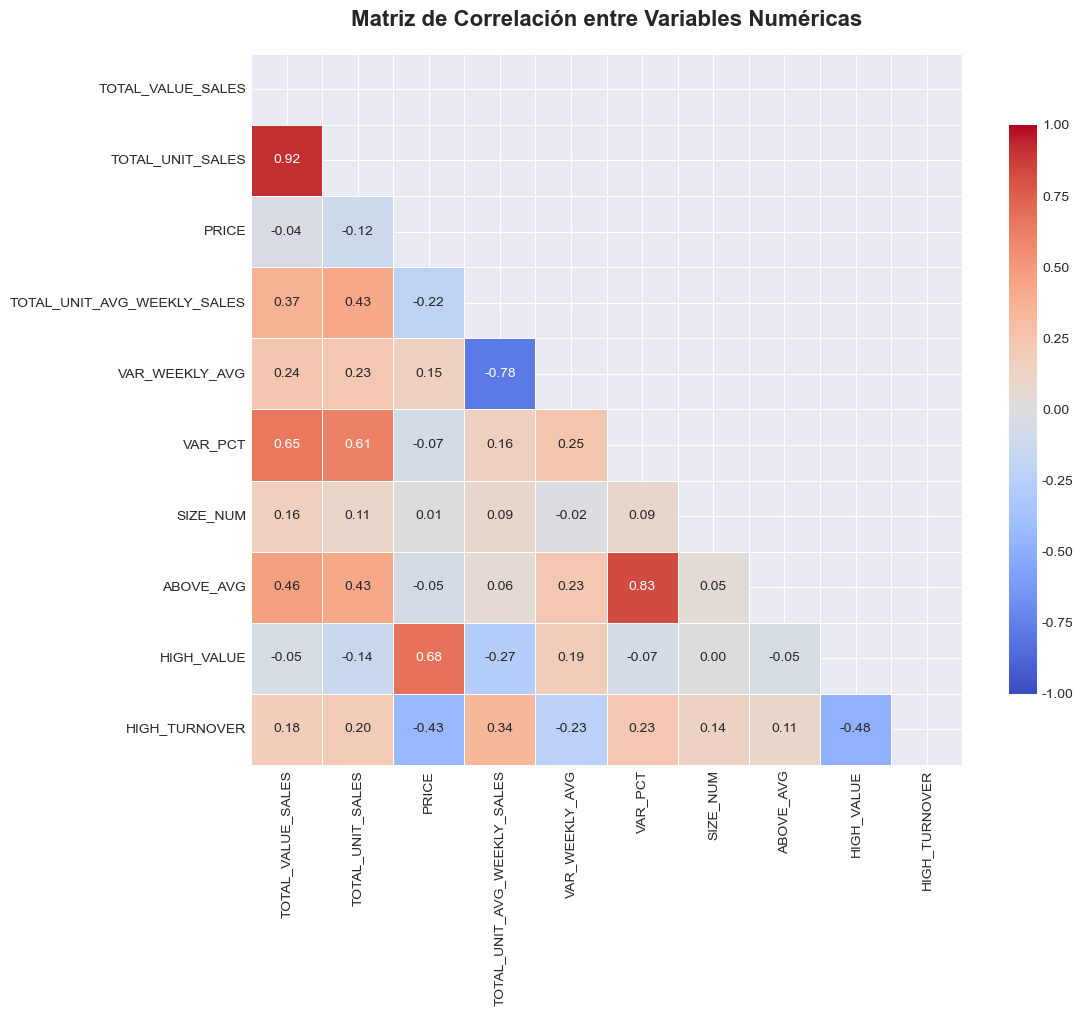


INSIGHTS DEL GRÁFICO 7: Matriz de Correlación entre Varibales Numéricas

────────────────────────────────────────────────────────────────────────────────────────────────────
• Correlaciones Significativas (|r| > 0.5):
────────────────────────────────────────────────────────────────────────────────────────────────────
  - TOTAL_VALUE_SALES ↔ TOTAL_UNIT_SALES: 0.916
  - VAR_PCT ↔ ABOVE_AVG: 0.827
  - PRICE ↔ HIGH_VALUE: 0.678
  - VAR_PCT ↔ TOTAL_VALUE_SALES: 0.653
  - TOTAL_UNIT_SALES ↔ VAR_PCT: 0.613
  - VAR_WEEKLY_AVG ↔ TOTAL_UNIT_AVG_WEEKLY_SALES: -0.782

────────────────────────────────────────────────────────────────────────────────────────────────────
Hallazgos e Interpretación
────────────────────────────────────────────────────────────────────────────────────────────────────

• CORRELACIONES POSITIVAS FUERTES (r > 0.6):

    1. TOTAL_VALUE_SALES ↔ TOTAL_UNIT_SALES: r = 0.92 (MUY FUERTE)
       - Las ventas en $ están casi perfectamente alineadas con las unidades vendidas 
      

In [201]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 7: Matriz de Correlación entre Variable Numéricas
# ══════════════════════════════════════════════════════════════

# Seleccionar variables numéricas clave
vars_numericas = ['TOTAL_VALUE_SALES', 'TOTAL_UNIT_SALES', 'PRICE', 
                  'TOTAL_UNIT_AVG_WEEKLY_SALES', 'VAR_WEEKLY_AVG', 'VAR_PCT',
                  'SIZE_NUM', 'ABOVE_AVG', 'HIGH_VALUE', 'HIGH_TURNOVER']

# Medir qué tan relacionadas están dos variables: valores entre -1 y +1
df_corr = df[vars_numericas].corr()

# ──────────────────────────────────────────────────────────────
# HEATMAP: Matriz de Correlación entre Variables Numéricas
# ──────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(df_corr, dtype=bool)) # Oculta la mitad superior de la matriz (triangular superior) para evitar redundancia
sns.heatmap(df_corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, center=0) # -1: azul, 0: blanco, +1: rojo
plt.title('Matriz de Correlación entre Variables Numéricas', fontsize=16, fontweight='bold', pad=20)

# Guardar y mostrar figura
plt.tight_layout()
plt.savefig('07_matriz_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()


# ══════════════════════════════════════════════════════════════
# INSIGHTS DEL GRÁFICO 7: Matriz de Correlación entre Variable Numéricas
# ══════════════════════════════════════════════════════════════

print("\n" + "="*100)
print('INSIGHTS DEL GRÁFICO 7: Matriz de Correlación entre Varibales Numéricas')
print("="*100 + "\n")

# ──────────────────────────────────────────────────────────────
# Mostrar Correlaciones Significativas (|r| > 0.5):
# ──────────────────────────────────────────────────────────────
print("─"*100)
print('• Correlaciones Significativas (|r| > 0.5):')
print("─"*100)

corr_pairs = df_corr.unstack()
corr_pairs = corr_pairs[abs(corr_pairs) > 0.5]
corr_pairs = corr_pairs[corr_pairs != 1.0]
corr_pairs = corr_pairs.sort_values(ascending=False).drop_duplicates()
for (var1, var2), corr in corr_pairs.head(10).items():
    print(f"  - {var1} ↔ {var2}: {corr:.3f}")

print("\n" + "─"*100)
print('Hallazgos e Interpretación')
print("─"*100)

print(f"""
• CORRELACIONES POSITIVAS FUERTES (r > 0.6):

    1. TOTAL_VALUE_SALES ↔ TOTAL_UNIT_SALES: r = 0.92 (MUY FUERTE)
       - Las ventas en $ están casi perfectamente alineadas con las unidades vendidas 
           → vender más unidades se traduce directamente en más ingresos.
       - Confirma que NO hay distorsiones significativas por descuentos o variaciones de precio que rompan esta relación.

    2. VAR_PCT ↔ ABOVE_AVG: r = 0.83 (FUERTE)
       - Los productos con mayor variación porcentual respecto al promedio tienden a estar clasificados como "por encima del promedio".
       - Confirma que la métrica de clasificación es coherente con el rendimiento real.

    3. PRICE ↔ HIGH_VALUE: r = 0.68 (MODERADA-FUERTE)
       - Los productos de mayor precio tienden a ser clasificados como "alto valor" al estar arriba de la mediana.
       - Esta correlación no aporta información nueva, solo confirma que la variable derivada fue creada correctamente.

    4. VAR_PCT ↔ TOTAL_VALUE_SALES: r = 0.65 (MODERADA)
       - Productos con mayor variación porcentual generan más ventas en $.
       - Los productos que más se desvían del promedio (por arriba) son los que más facturan. Esto identifica a los "best sellers".

    5. TOTAL_UNIT_SALES ↔ VAR_PCT: r = 0.61 (MODERADA)
       - Similar a la anterior pero con unidades, los productos con alto VAR_PCT también venden más unidades.

• CORRELACIÓN NEGATIVA FUERTE:

    6. VAR_WEEKLY_AVG ↔ TOTAL_UNIT_AVG_WEEKLY_SALES: r = -0.78 (FUERTE NEGATIVA)
       - Los productos con mayor promedio semanal de ventas tienen MENOR variación semanal, y viceversa.
       - Los productos de alta rotación son más estables (predecibles) mientras que los de baja rotación son más volátiles (impredecibles):
           Alta demanda = demanda estable (productos básicos/staples)
           Baja demanda = demanda errática (productos de nicho/ocasionales)

• CORRELACIONES DÉBILES O NULAS:

    7. PRICE ↔ TOTAL_VALUE_SALES: r = -0.04 (NULA)
       - El precio no tiene relación con las ventas totales en $.
       - Productos caros y baratos generan niveles similares de ventas totales. Los baratos compensan con volumen, los caros con ticket.
       - Esto desmiente la suposición de que "productos más caros = más ingresos".

    8. PRICE ↔ TOTAL_UNIT_SALES: r = -0.12 (MUY DÉBIL NEGATIVA)
       - Productos más caros venden ligeramente menos unidades, pero el efecto es casi despreciable.
       - La sensibilidad al precio en este mercado es baja. 

    9. SIZE_NUM ↔ casi todas las variables: r < 0.16 (NULA)
       - El tamaño del producto no predice ventas, precio, ni rotación.
       - Productos grandes y pequeños se venden por igual. El tamaño no es un factor diferenciador de rendimiento.

    10. HIGH_VALUE ↔ HIGH_TURNOVER: r = -0.48 (MODERADA NEGATIVA)
        - Productos de "alto valor" (caros) tienden a no ser de "alta rotación", y viceversa:
            Productos premium = margen alto pero baja rotación
            Productos masivos = margen bajo pero alta rotación
""")

### 5.2 Scatter Plots

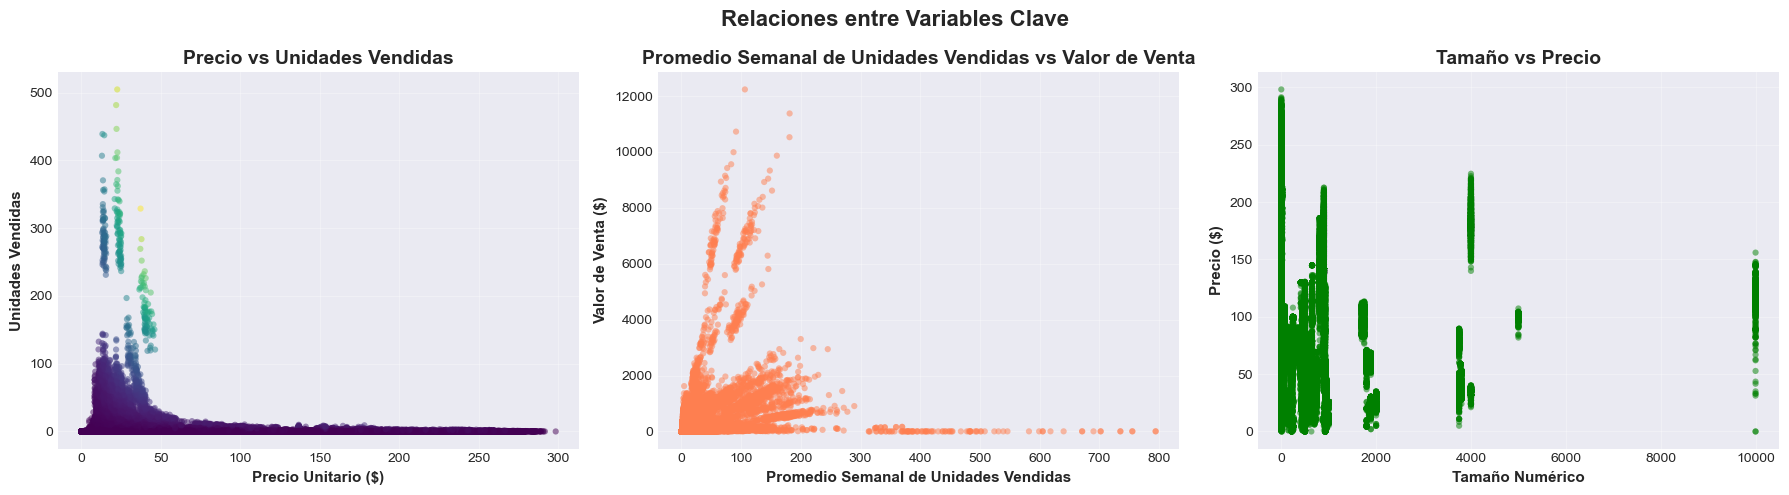


INSIGHTS DEL GRÁFICO 8: Relaciones entre Variables Clave

────────────────────────────────────────────────────────────────────────────────────────────────────
Scatter Plot 1: Precio vs Unidades Vendidas
────────────────────────────────────────────────────────────────────────────────────────────────────

• Hallazgos:
    - Forma de "L invertida": la masa de datos se concentra en la esquina inferior izquierda (precios bajos + pocas unidades).
    - Los productos de mayor volumen (100-500 unidades) se concentran exclusivamente en el rango de precios bajos ($5-$50).
    - Productos con precio >$100 nunca superan ~50 unidades vendidas.
    - El color (valor de ventas en $) muestra que los puntos más brillantes (mayor $) están en precios de $10-$50 con unidades altas 
        → el "sweet spot" del negocio está en productos de precio bajo-medio con alto volumen.
    - A medida que el precio sube, el máximo de unidades posibles decrece.

• Interpretación:
    - Relación clásica de ELASTICIDAD

In [203]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 8: Relaciones entre Variables Clave
# ══════════════════════════════════════════════════════════════

# Crear los gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # 1 fila, 3 columnas. Tamaño total: 18 pulgadas de ancho × 5 de alto
fig.suptitle('Relaciones entre Variables Clave', fontsize=16, fontweight='bold') 


# ──────────────────────────────────────────────────────────────
# SCATTER PLOT 1: Precio vs Unidades Vendidas
# ──────────────────────────────────────────────────────────────
axes[0].scatter(df['PRICE'], df['TOTAL_UNIT_SALES'], # eje X: precio, eje Y: unidades
                alpha=0.5, s=20, c=df['TOTAL_VALUE_SALES'], # 50% transparente, 20 pixeles, cada punto se colorea según su valor de venta
                cmap='viridis', edgecolors='none') # escala de morado (bajo) a amarillo (alto), sin borde
axes[0].set_title('Precio vs Unidades Vendidas', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Precio Unitario ($)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Unidades Vendidas', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3) # Líneas guía 30% visibles


# ──────────────────────────────────────────────────────────────
# SCATTER PLOT 2: Promedio Semanal de Unidades Vendidas vs Valor de Venta
# ──────────────────────────────────────────────────────────────
axes[1].scatter(df['TOTAL_UNIT_AVG_WEEKLY_SALES'], df['TOTAL_VALUE_SALES'], # eje X: promedio de unidades vendidas por semana, eje Y: valor total de ventas 
                alpha=0.5, s=20, edgecolors='none', color='coral') # Todos los puntos del mismo color, no hay 3ra variable
axes[1].set_title('Promedio Semanal de Unidades Vendidas vs Valor de Venta', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Promedio Semanal de Unidades Vendidas', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Valor de Venta ($)', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3)


# ──────────────────────────────────────────────────────────────
# SCATTER PLOT 3: Tamaño vs Precio
# ──────────────────────────────────────────────────────────────
axes[2].scatter(df['SIZE_NUM'], df['PRICE'], # eje X: tamaño numérico del producto, eje Y: precio
                alpha=0.5, s=20, edgecolors='none', color='green')
axes[2].set_title('Tamaño vs Precio', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Tamaño Numérico', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Precio ($)', fontsize=11, fontweight='bold')
axes[2].grid(True, alpha=0.3)


# Guardar y mostrar figura
plt.tight_layout()
plt.savefig('08_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()



# ══════════════════════════════════════════════════════════════
# INSIGHTS DEL GRÁFICO 8: Relaciones entre Variables Clave
# ══════════════════════════════════════════════════════════════

print("\n" + "="*100)
print('INSIGHTS DEL GRÁFICO 8: Relaciones entre Variables Clave')
print("="*100 + "\n")

# ──────────────────────────────────────────────────────────────
# Resumen de Scatter Plot 1: Precio vs Unidades Vendidas
# ──────────────────────────────────────────────────────────────
print("─"*100)
print('Scatter Plot 1: Precio vs Unidades Vendidas')
print("─"*100)

print(f"""
• Hallazgos:
    - Forma de "L invertida": la masa de datos se concentra en la esquina inferior izquierda (precios bajos + pocas unidades).
    - Los productos de mayor volumen (100-500 unidades) se concentran exclusivamente en el rango de precios bajos ($5-$50).
    - Productos con precio >$100 nunca superan ~50 unidades vendidas.
    - El color (valor de ventas en $) muestra que los puntos más brillantes (mayor $) están en precios de $10-$50 con unidades altas 
        → el "sweet spot" del negocio está en productos de precio bajo-medio con alto volumen.
    - A medida que el precio sube, el máximo de unidades posibles decrece.

• Interpretación:
    - Relación clásica de ELASTICIDAD PRECIO-DEMANDA: a mayor precio, menor volumen.
    - La correlación general es débil (r=-0.12) porque la mayoría de productos están en el rango de $10-$50, donde la variación de unidades es enorme.
    - El mercado es fundamentalmente de precio bajo y alto volumen.
    - Los productos premium (>$100) existen pero son un nicho marginal en volumen.
    - El "motor de ingresos" está en productos de $10-50 que venden 50-500 unidades.
""")


# ──────────────────────────────────────────────────────────────
# Resumen de Scatter Plot 2: Promedio Semanal de Unidades Vendidas vs Valor de Venta
# ──────────────────────────────────────────────────────────────
print("\n" + "─"*100)
print('Scatter Plot 2: Promedio Semanal de Unidades Vendidas vs Valor de Venta')
print("─"*100)

print(f"""
• Hallazgos:
    - Relación positiva: a mayor promedio semanal de unidades, mayor valor total.
    - La nube de puntos forma un "cono" que se abre hacia la derecha 
        → a mayor promedio semanal, mayor dispersión del valor de venta.
    - La mayoría de datos se concentran en promedio semanal <100 uds y valor <$2,000.
    - Outliers extremos visibles:
       - Un producto con promedio ~100 uds/semana genera ~$12,000 en valor.
       - Varios productos con promedio ~150-200 uds/semana generan $6,000-$10,000.
    - Existen puntos en el eje x con promedio semanal alto (>300 uds) pero valor relativamente bajo (<$1,000) 
        → productos de muy bajo precio pero altísima rotación.

• Interpretación:
    - La relación es fuerte pero no lineal: el valor crece más que proporcionalmente para algunos productos de alta rotación 
        → "productos estrella" 
    - Los outliers superiores son probablemente productos de precio medio con rotación excepcional 
        → productos más valiosos del portafolio
    - Los puntos de alto volumen/bajo valor (derecha-abajo) son productos de precio muy bajo que generan tráfico pero poco ingreso individual.
    - El "cono" de dispersión indica que el promedio semanal es necesario pero no suficiente para garantizar alto valor 
        → el precio también importa.
""")


# ──────────────────────────────────────────────────────────────
# Resumen de Scatter Plot 3: Tamaño Numérico vs Precio
# ──────────────────────────────────────────────────────────────
print("\n" + "─"*100)
print('Scatter Plot 3: Tamaño Numérico vs Precio')
print("─"*100)

print(f"""
• Hallazgos:
    - No existe relación lineal clara entre tamaño y precio (r=0.01 en la matriz).
    - Los datos se agrupan en columnas verticales discretas, lo que indica que los tamaños son estandarizados.
    - Tamaños más comunes: ~250ml, ~500ml, ~1000ml, ~2000ml, ~4000ml.
    - Para un mismo tamaño, el rango de precios es enorme:
         1000ml: desde $5 hasta $250.
         500ml: desde $5 hasta $150.
    - Productos grandes (>5000ml) tienen precios dispersos pero generalmente <$150.
    - Un punto aislado: producto de ~10,000ml con precio muy bajo (~$20) → probablemente producto a granel/industrial.

• Interpretación:
    - El tamaño no determina el precio: lo que determina el precio es la MARCA, el SEGMENTO y el TIPO DE PRODUCTO.
    - No hay economía de escala clara: productos más grandes no son proporcionalmente más baratos 
        → posible oportunidad de crear presentaciones "jumbo" con descuento por volumen para incentivar compras más grandes.
""")

## 6. Visualizar la distribución geográfica de las ventas:

Si es posible, utiliza mapas o gráficos de barras apiladas para visualizar las ventas por región. Esto puede ayudar a identificar qué regiones tienen el mayor o menor rendimiento.

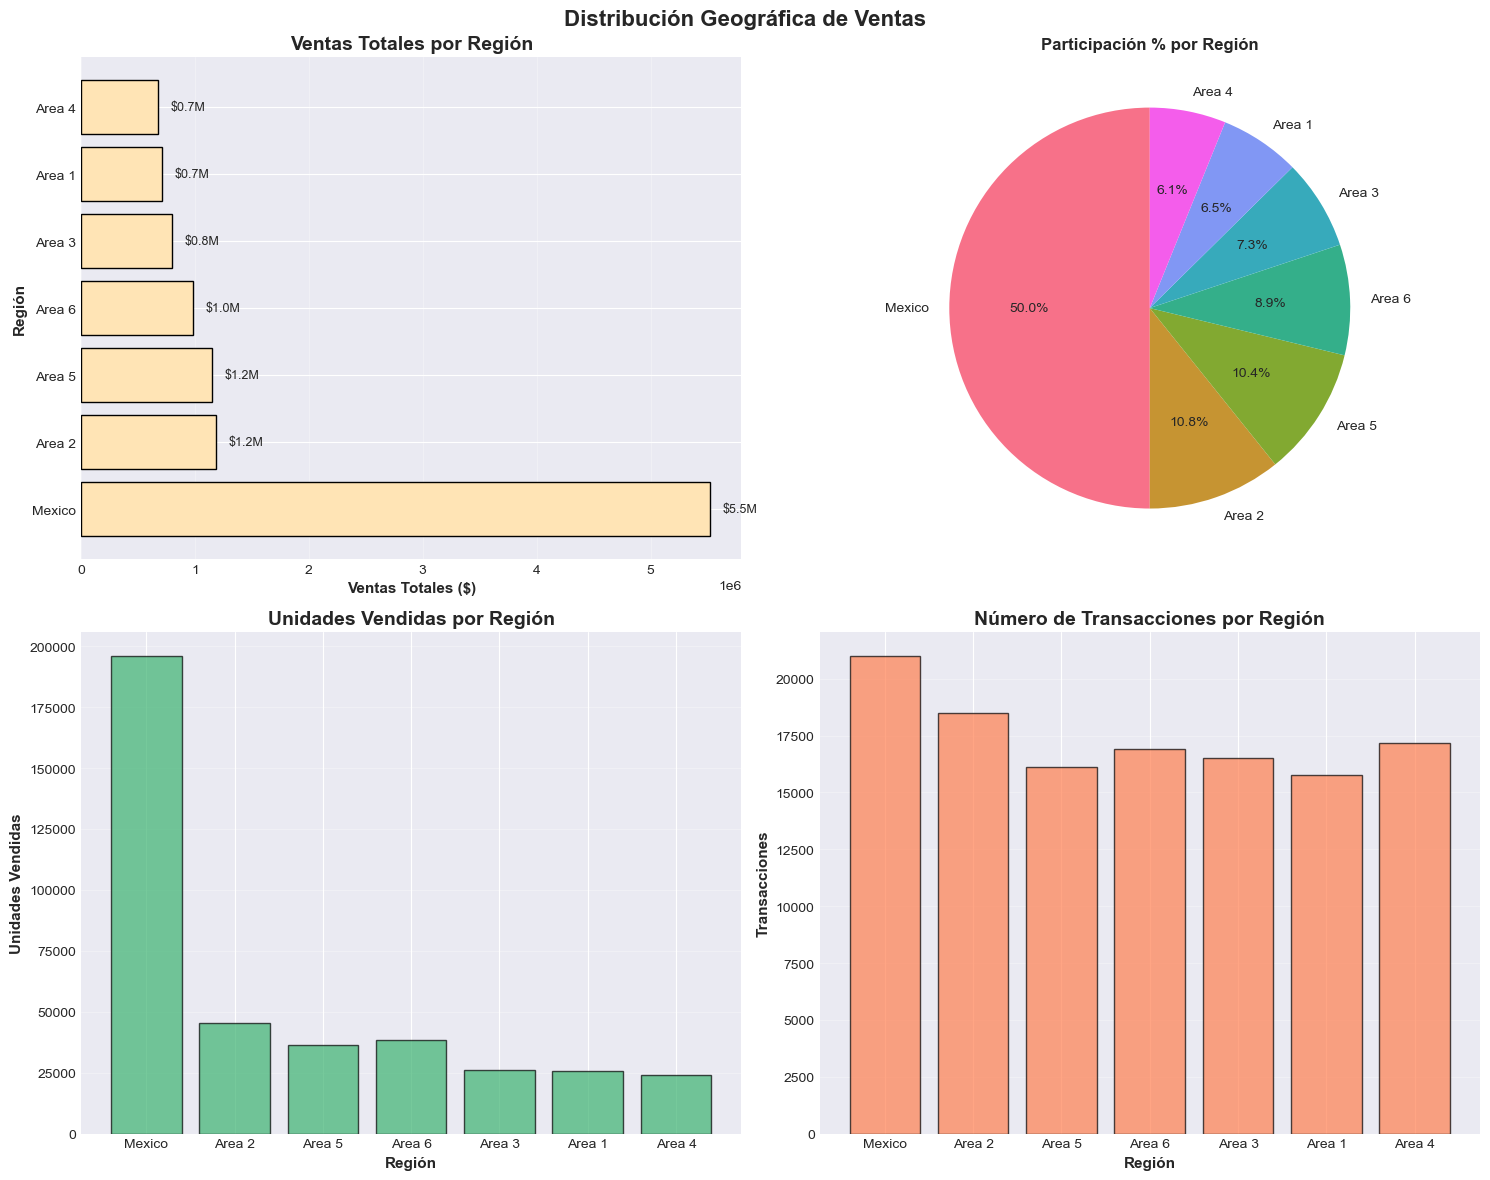


INSIGHTS DEL GRÁFICO 9: Distribución Geográfica de Ventas


  Región               Ventas           Transacciones        Unidades      Ticket Promedio
──────────────────────────────────────────────────────────────────────────────────────────
  - Mexico  |  $5,521,429.32 (50.0%)  |  20,990 (17.2%)  |  195,880 (50.0%)  |  $263       
  - Area 2  |  $1,188,796.15 (10.8%)  |  18,505 (15.2%)  |  45,320 (11.6%)  |  $64        
  - Area 5  |  $1,153,335.54 (10.4%)  |  16,135 (13.2%)  |  36,267 (9.3%)  |  $71        
  - Area 6  |  $983,957.57   (8.9%)  |  16,913 (13.9%)  |  38,585 (9.8%)  |  $58        
  - Area 3  |  $803,655.34   (7.3%)  |  16,496 (13.5%)  |  25,896 (6.6%)  |  $49        
  - Area 1  |  $714,249.98   (6.5%)  |  15,781 (12.9%)  |  25,792 (6.6%)  |  $45        
  - Area 4  |  $677,436.00   (6.1%)  |  17,182 (14.1%)  |  24,020 (6.1%)  |  $39        
──────────────────────────────────────────────────────────────────────────────────────────
 TOTAL      |  $11,042,859.89        

In [209]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 9: Distribución Geográfica de Ventas
# ══════════════════════════════════════════════════════════════

# Agrupar ventas y unidades por región
ventas_region = df.groupby('REGION_SHORT').agg({ # Separa en 7 regiones (7 filas)
    'TOTAL_VALUE_SALES': 'sum', # Suma todos los valores de ventas
    'TOTAL_UNIT_SALES': 'sum', # Suma todas las unidades del montón
    'ITEM_CODE': 'count' # Cuenta cuántas filas (transacciones) hay por región. Cada fila = 1 transacción
}).rename(columns={'ITEM_CODE': 'NUM_TRANSACTIONS'}).sort_values('TOTAL_VALUE_SALES', ascending=False) # Nombra para número de transacciones y orderna de mayor a menor ventas

# Crear gráficos
fig, axes = plt.subplots(2, 2, figsize=(15, 12)) # 2 filas, 2 columnas
fig.suptitle('Distribución Geográfica de Ventas', fontsize=16, fontweight='bold')


# ──────────────────────────────────────────────────────────────
# BARRA HORIZONTALES: Ventas por Región
# ──────────────────────────────────────────────────────────────
axes[0, 0].barh(ventas_region.index, ventas_region['TOTAL_VALUE_SALES'], color='moccasin', edgecolor='black') # Eje Y: nombres de regiones, Eje X: ventas totales en $M
axes[0, 0].set_title('Ventas Totales por Región', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Ventas Totales ($)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Región', fontsize=11, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Poner valores
for i, v in enumerate(ventas_region['TOTAL_VALUE_SALES']): # Para cada valor total de ventas (de las 7 regiones)
    axes[0, 0].text(v + ventas_region['TOTAL_VALUE_SALES'].max()*0.02, i, # Coloca texto al final de la barra + 2% de espacio extra
                     f'${v/1e6:.1f}M', va='center', fontsize=9) # v/1e6 → divide entre 1,000,000 para convertir a millones


# ──────────────────────────────────────────────────────────────
# PIE: Participación %
# ──────────────────────────────────────────────────────────────
axes[0, 1].pie(ventas_region['TOTAL_VALUE_SALES'], labels=ventas_region.index, # El tamaño de cada rebanada es el de las ventas y la etiqueta es la región
               autopct='%1.1f%%', startangle=90) # Muestra el porcentaje automáticamente dentro de cada rebanada
axes[0, 1].set_title('Participación % por Región', fontsize=12, fontweight='bold') # Empieza a dibujar desde las 12 en punto (arriba) en vez de las 3


# ──────────────────────────────────────────────────────────────
# BARRAS VERTICALES 1: Unidades por Región
# ──────────────────────────────────────────────────────────────
axes[1, 0].bar(ventas_region.index, ventas_region['TOTAL_UNIT_SALES'], # Eje X: nombres de regiones, Eje Y: unidades vendidas
               color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Unidades Vendidas por Región', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Región', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Unidades Vendidas', fontsize=11, fontweight='bold')
axes[1, 0].tick_params(axis='x')
axes[1, 0].grid(axis='y', alpha=0.3)


# ──────────────────────────────────────────────────────────────
# BARRAS VERTICALES 2: Transacciones por Región
# ──────────────────────────────────────────────────────────────
axes[1, 1].bar(ventas_region.index, ventas_region['NUM_TRANSACTIONS'], # Eje X: nombres de regiones, Eje Y: número de transacciones
               color='coral', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Número de Transacciones por Región', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Región', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Transacciones', fontsize=11, fontweight='bold')
axes[1, 1].tick_params(axis='x')
axes[1, 1].grid(axis='y', alpha=0.3)


# Guardar y mostrar figura
plt.tight_layout()
plt.savefig('09_distribucion_geografica.png', dpi=300, bbox_inches='tight')
plt.show()



# ══════════════════════════════════════════════════════════════
# INSIGHTS DEL GRÁFICO 9: Distribución Geográfica de Ventas
# ══════════════════════════════════════════════════════════════

print("\n" + "="*100)
print('INSIGHTS DEL GRÁFICO 9: Distribución Geográfica de Ventas')
print("="*100 + "\n")


# ──────────────────────────────────────────────────────────────
# Resumen de Distribución Geográfica de Ventas
# ──────────────────────────────────────────────────────────────
print(f"\n  {'Región':<13} {'Ventas':>13} {'Transacciones':>23} {'Unidades':>15} {'Ticket Promedio':>20}")
print("─"*90)
for region in ventas_region.index: # Para cada región
    ventas = ventas_region.loc[region, 'TOTAL_VALUE_SALES'] # Las ventas de la región
    pct_v = (ventas / ventas_region['TOTAL_VALUE_SALES'].sum()) * 100 # Calcula el porcentaje de ventas: ventas de esta región / total de todas las regiones × 100
    trans = ventas_region.loc[region, 'NUM_TRANSACTIONS'] # El número de transacciones de la región
    pct_t = (trans / ventas_region['NUM_TRANSACTIONS'].sum()) * 100 # Calcula el porcentaje de transacciones
    uds = ventas_region.loc[region, 'TOTAL_UNIT_SALES'] # El número de unidades vendidas en la región
    pct_u = (uds / ventas_region['TOTAL_UNIT_SALES'].sum()) * 100 # Calcula el porcentaje de unidades vendidas
    ticket_prom = (ventas / trans) # Calcula el ticket promedio por transacción
    print(f"  - {region:6}  |  ${ventas:<12,.2f} ({pct_v:<2.1f}%)  |  {trans:<6,} ({pct_t:<2.1f}%)  |  {uds:<6,.0f} ({pct_u:<2.1f}%)  |  ${ticket_prom:<10,.0f}")
print("─"*90)
print(f" {'TOTAL':<9}  |  ${ventas_region['TOTAL_VALUE_SALES'].agg('sum'):<19,.2f}  |  {ventas_region['NUM_TRANSACTIONS'].agg('sum'):<9,}trans  |  {ventas_region['TOTAL_UNIT_SALES'].agg('sum'):<11,.0f}uds")    
print("─"*90)

# ──────────────────────────────────────────────────────────────
# Hallazgos e Interpretación
# ──────────────────────────────────────────────────────────────
print(f"""
• Región Líder: {ventas_region.index[0]}
    - Concentra el 50.0% de las ventas y de las unidades vendidas, aunque tiene 17.2% transacciones
    - Tiene un ticket promedio 4x mayor que Area 2 y 6.7x mayor que Area 4
        México: $5.5M / 20,990 trans = ~$263 por transacción
        Area 2: $1.2M / 18,505 trans = ~$64 por transacción
        Area 4: $0.7M / 17,182 trans = ~$39 por transacción
    → Esto indica que en México se venden productos más caros, en mayor cantidad por transacción, o ambos.

• Las Transacciones están más Distribuidas que las Ventas
    - Rango de transacciones: 15,781 a 20,990 (variación de 1.3x)
    - Rango de ventas: $677K a $5,521K (variación de 8.2x)
    → Esto confirma que la diferencia está en el valor por transacción.

• Top 3 regiones concentran {(ventas_region['TOTAL_VALUE_SALES'].head(3).sum() / ventas_region['TOTAL_VALUE_SALES'].sum() * 100):.1f}% de ventas
""")

## 7. Identificar posibles outliers y anomalías:

Utiliza gráficos de caja (boxplots) para identificar posibles outliers en los datos de ventas por producto, categoría o región. Identificar outliers puede ayudar a entender mejor los patrones inusuales o anómalos en los datos.

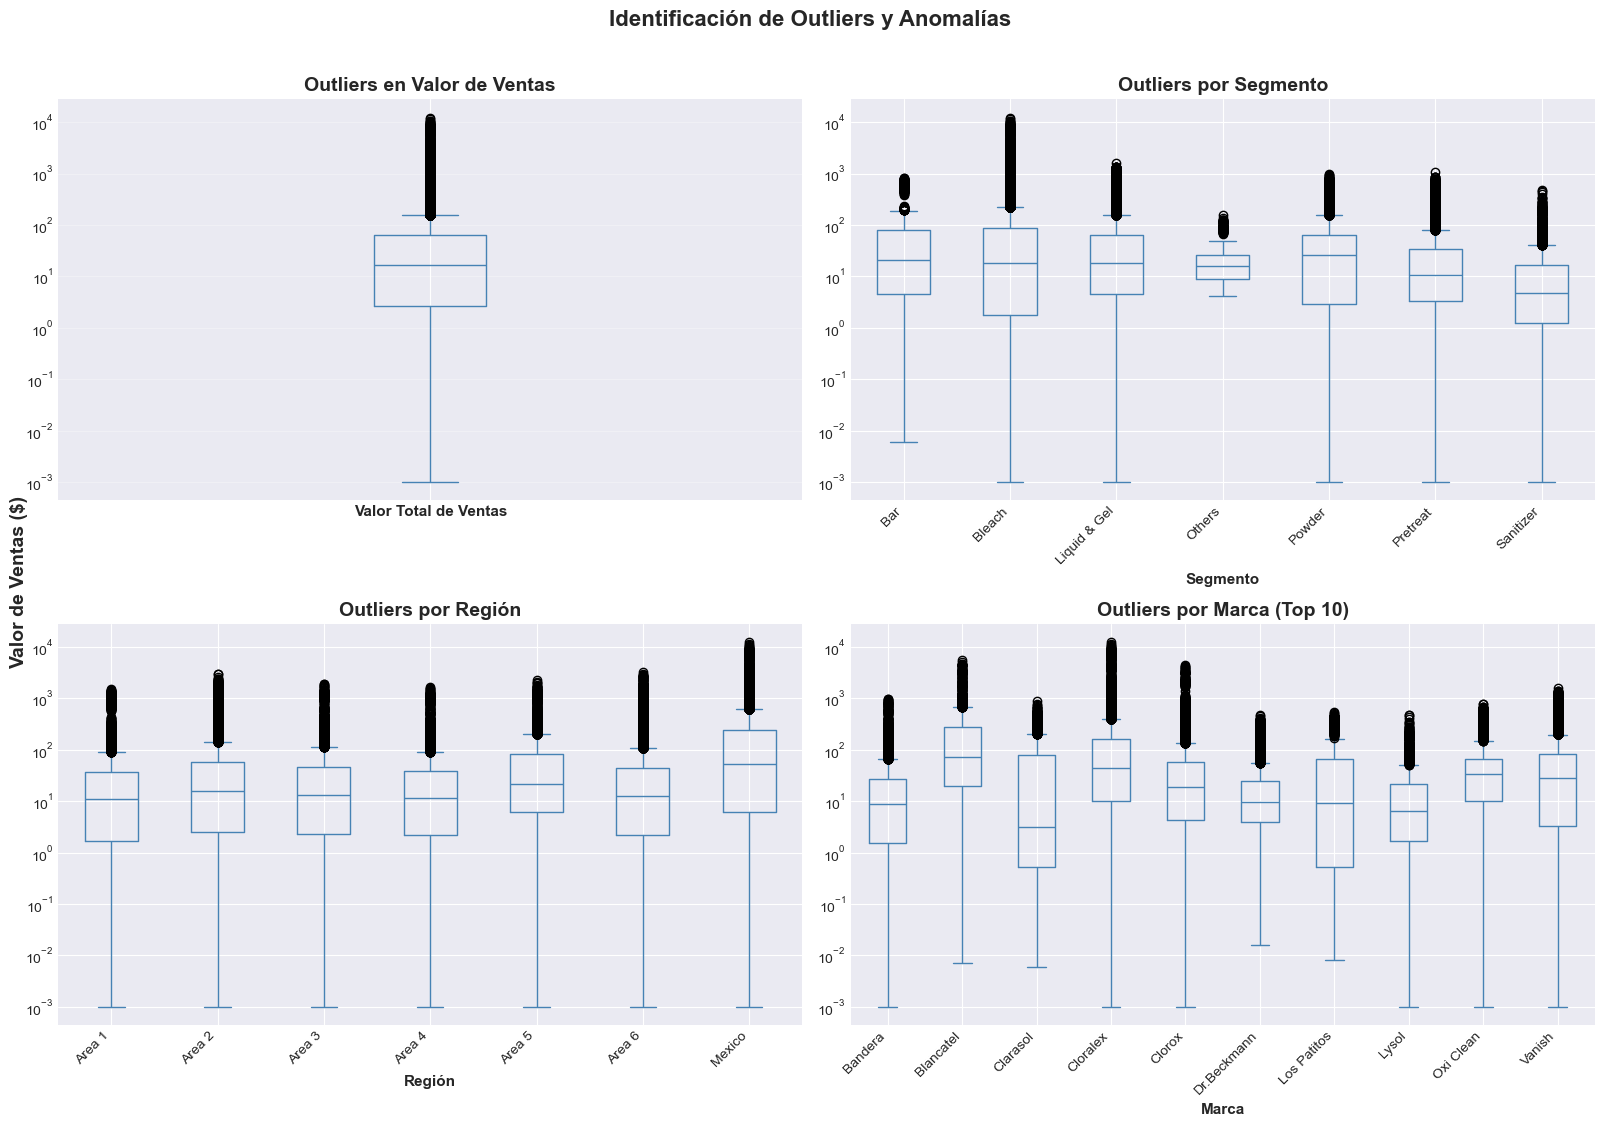


INSIGHTS DEL GRÁFICO 10: Identificación de Outliers y Anomalías

──────────────────────────────────────────────────────────────────────────────────────────
Método IQR (Rango Intercuartílico) - Ventas Totales
──────────────────────────────────────────────────────────────────────────────────────────

  Cálculo del Rango Intercuartílico (IQR):
  ─────────────────────────────────────────
  Q1 (percentil 25%)     : $      2.66
  Q3 (percentil 75%)     : $     62.96
  IQR (Q3 - Q1)          : $     60.30
  Límite inferior        : $    -87.79  (Q1 - 1.5×IQR)
  Límite superior        : $    153.41  (Q3 + 1.5×IQR)

  Resumen de Outliers:
  ─────────────────────────────────────────
  Total de outliers       : 14,241  (11.67%)
  Outliers superiores (>$): 14,241  (ventas inusualmente ALTAS)
  Outliers inferiores (<$):      0  (ventas inusualmente BAJAS)
  Anomalías (< $0.01)     :    491  (posibles errores de datos)

───────────────────────────────────────────────────────────────────────────────

In [213]:
# ══════════════════════════════════════════════════════════════
# GRÁFICO 10: Identificación de Outliers y Anomalías
# ══════════════════════════════════════════════════════════════

# Crear los gráficos
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.text(0.0001, 0.5, 'Valor de Ventas ($)', va='center', rotation='vertical', fontsize=14, fontweight='bold') # Misma descripción para ambos gráficos en eje Y

# ──────────────────────────────────────────────────────────────
# BOXPLOT 1: Outliers generales en Valor de Ventas
# ──────────────────────────────────────────────────────────────
df.boxplot(column='TOTAL_VALUE_SALES', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_yscale('log') # Escala logarítimica para poder visualizar la caja a pesar de los outliers
plt.sca(axes[0, 0])
plt.title('')  # Elimina el título automático
axes[0, 0].set_title('Outliers en Valor de Ventas', fontsize=14, fontweight='bold')
axes[0, 0].set_xticklabels(['Valor Total de Ventas'], fontsize=11, fontweight='bold') 
axes[0, 0].grid(axis='y', alpha=0.3)


# ──────────────────────────────────────────────────────────────
# BOXPLOT 2: Outliers por Segmento
# ──────────────────────────────────────────────────────────────
df.boxplot(column='TOTAL_VALUE_SALES', by='SEGMENT', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_yscale('log') # Escala logarítimica para poder visualizar las cajas a pesar de los outliers
plt.sca(axes[0, 1])
plt.title('')  # Elimina el título automático
axes[0, 1].set_title('Outliers por Segmento', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Segmento', fontsize=11, fontweight='bold')
plt.xticks(rotation=45, ha='right')


# ──────────────────────────────────────────────────────────────
# BOXPLOT 3: Outliers por Región
# ──────────────────────────────────────────────────────────────
df.boxplot(column='TOTAL_VALUE_SALES', by='REGION_SHORT', ax=axes[1, 0], color='steelblue')
axes[1, 0].set_yscale('log') # Escala logarítimica para poder visualizar las cajas a pesar de los outliers
plt.sca(axes[1, 0])
plt.title('')  # Elimina el título automático
axes[1, 0].set_title('Outliers por Región', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Región', fontsize=11, fontweight='bold')
plt.xticks(rotation=45, ha='right')


# ──────────────────────────────────────────────────────────────
# BOXPLOT 4: Outliers por Top 10 Marcas (producto)
# ──────────────────────────────────────────────────────────────
top10_marcas = df.groupby('BRAND')['TOTAL_VALUE_SALES'].sum().nlargest(10).index  # Las 10 marcas con más ventas
df_top10 = df[df['BRAND'].isin(top10_marcas)]  # Filtra solo esas top 10 marcas

df_top10.boxplot(column='TOTAL_VALUE_SALES', by='BRAND', ax=axes[1, 1], color='steelblue')
axes[1, 1].set_yscale('log') # Escala logarítimica para poder visualizar las cajas a pesar de los outliers
plt.sca(axes[1, 1])
plt.title('')  # Elimina título automático
axes[1, 1].set_title('Outliers por Marca (Top 10)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Marca', fontsize=11, fontweight='bold')
plt.xticks(rotation=45, ha='right')


# Guardar y mostrar figura
plt.tight_layout()
fig.suptitle('Identificación de Outliers y Anomalías', fontsize=16, fontweight='bold', y=1.02) # Título para toda la figura
plt.savefig('10_outliers.png', dpi=300, bbox_inches='tight')
plt.show()



# ══════════════════════════════════════════════════════════════
# INSIGHTS DEL GRÁFICO 10: Identificación de Outliers y Anomalías
# ══════════════════════════════════════════════════════════════
print("\n" + "="*100)
print('INSIGHTS DEL GRÁFICO 10: Identificación de Outliers y Anomalías')
print("="*100)


# ──────────────────────────────────────────────────────────────
# CÁLCULO DE OUTLIERS CON MÉTODO IQR
# ──────────────────────────────────────────────────────────────
print("\n" + "─"*90)
print('Método IQR (Rango Intercuartílico) - Ventas Totales')
print("─"*90)

Q1 = df['TOTAL_VALUE_SALES'].quantile(0.25) # Percentil 25% 
Q3 = df['TOTAL_VALUE_SALES'].quantile(0.75) # Percentil 75%
IQR = Q3 - Q1 # Rango Intercuartílico: la distancia entre Q1 y Q3. Contiene el 50% central de los datos
limite_inferior = Q1 - 1.5 * IQR # El umbral por encima del cual un dato se considera outlier
limite_superior = Q3 + 1.5 * IQR # El umbral por debajo del cual un dato se considera outlier

outliers = df[(df['TOTAL_VALUE_SALES'] < limite_inferior) | # Filtra los datos que están fuera de los límites
              (df['TOTAL_VALUE_SALES'] > limite_superior)] 

outliers_superiores = df[df['TOTAL_VALUE_SALES'] > limite_superior] # Filtra solo los que están por arriba del límite
outliers_inferiores = df[df['TOTAL_VALUE_SALES'] < limite_inferior] # Filtra solo los que están por abajo del límite

anomalias_bajo = df[df['TOTAL_VALUE_SALES'] < 0.01] # Filtra registros con ventas menores a 1 centavo (posibles anomalías de precios muy bajos)

print(f"""
  Cálculo del Rango Intercuartílico (IQR):
  ─────────────────────────────────────────
  Q1 (percentil 25%)     : ${Q1:>10,.2f}
  Q3 (percentil 75%)     : ${Q3:>10,.2f}
  IQR (Q3 - Q1)          : ${IQR:>10,.2f}
  Límite inferior        : ${limite_inferior:>10,.2f}  (Q1 - 1.5×IQR)
  Límite superior        : ${limite_superior:>10,.2f}  (Q3 + 1.5×IQR)

  Resumen de Outliers:
  ─────────────────────────────────────────
  Total de outliers       : {len(outliers):>6,}  ({len(outliers)/len(df)*100:.2f}%)
  Outliers superiores (>$): {len(outliers_superiores):>6,}  (ventas inusualmente ALTAS)
  Outliers inferiores (<$): {len(outliers_inferiores):>6,}  (ventas inusualmente BAJAS)
  Anomalías (< $0.01)     : {len(anomalias_bajo):>6,}  (posibles errores de datos)
""")


# ──────────────────────────────────────────────────────────────
# OUTLIERS por Segmento
# ──────────────────────────────────────────────────────────────
print("─"*90)
print('Outliers por Segmento')
print("─"*90)

print(f"\n  {'Segmento':<15} {'Total Registros':>15} {'Outliers':>10} {'% Outliers':>12} {'Max Venta':>12}")
print(f"  {'─'*15} {'─'*15} {'─'*10} {'─'*12} {'─'*12}")

for segmento in df['SEGMENT'].unique(): # Para cada segmento
    df_seg = df[df['SEGMENT'] == segmento] # Filtra solo las filas de ese segmento
    q1_s = df_seg['TOTAL_VALUE_SALES'].quantile(0.25)
    q3_s = df_seg['TOTAL_VALUE_SALES'].quantile(0.75)
    iqr_s = q3_s - q1_s # Calcula IQR solo para ese segmento
    lim_sup_s = q3_s + 1.5 * iqr_s 
    outliers_s = df_seg[df_seg['TOTAL_VALUE_SALES'] > lim_sup_s] # Filtra los outliers de ese segmento usando su propio límite
    max_venta = df_seg['TOTAL_VALUE_SALES'].max() # La venta más alta del segmento
    
    print(f"  {segmento:<15} {len(df_seg):>15,} {len(outliers_s):>10,} {len(outliers_s)/len(df_seg)*100:>11.1f}% ${max_venta:>11,.2f}")


# ──────────────────────────────────────────────────────────────
# OUTLIERS por Región
# ──────────────────────────────────────────────────────────────
print(f"\n\n" + "─"*90)
print('Outliers por Región')
print("─"*90)

print(f"\n  {'Región':<10} {'Total Registros':>15} {'Outliers':>10} {'% Outliers':>12} {'Max Venta':>12} {'Ticket Prom':>12}")
print(f"  {'─'*10} {'─'*15} {'─'*10} {'─'*12} {'─'*12} {'─'*12}")

for region in df['REGION_SHORT'].unique():
    df_reg = df[df['REGION_SHORT'] == region]
    q1_r = df_reg['TOTAL_VALUE_SALES'].quantile(0.25)
    q3_r = df_reg['TOTAL_VALUE_SALES'].quantile(0.75)
    iqr_r = q3_r - q1_r
    lim_sup_r = q3_r + 1.5 * iqr_r
    outliers_r = df_reg[df_reg['TOTAL_VALUE_SALES'] > lim_sup_r]
    max_venta = df_reg['TOTAL_VALUE_SALES'].max()
    ticket_prom = df_reg['TOTAL_VALUE_SALES'].mean() # Calcula el promedio de venta por transacción en esa región
    
    print(f"  {region:<10} {len(df_reg):>15,} {len(outliers_r):>10,} {len(outliers_r)/len(df_reg)*100:>11.1f}% ${max_venta:>11,.2f} ${ticket_prom:>11,.2f}")


# ──────────────────────────────────────────────────────────────
# OUTLIERS EXTREMOS: Top 10 Transacciones más Altas
# ──────────────────────────────────────────────────────────────
print(f"\n\n" + "─"*90)
print('Top 10 Transacciones Más Altas (Outliers Extremos)')
print("─"*90)

# Seleccionar las 10 filas con el valor más alto en TOTAL_VALUE_SALES
top10_outliers = df.nlargest(10, 'TOTAL_VALUE_SALES')[['DATE', 'BRAND', 'SEGMENT', 'FORMAT', 'REGION_SHORT', 'TOTAL_VALUE_SALES', 'TOTAL_UNIT_SALES']] # Con sólo estas 7 columnas

print(f"\n  {'#':>3} {'Fecha':>12} {'Marca':<12} {'Segmento':<13} {'Formato':<10} {'Región':<8} {'Venta ($)':>12} {'Unidades':>10}")
print(f"  {'─'*3} {'─'*12} {'─'*12} {'─'*13} {'─'*10} {'─'*8} {'─'*12} {'─'*10}")

for i, (idx, row) in enumerate(top10_outliers.iterrows(), 1): # Itera fila por fila del dataframe y agrega un contador que empieza en 1
    print(f"  {i:>3} {str(row['DATE'])[:10]:>12} {row['BRAND']:<12} {row['SEGMENT']:<13} {row['FORMAT']:<10} {row['REGION_SHORT']:<8} ${row['TOTAL_VALUE_SALES']:>11,.2f} {row['TOTAL_UNIT_SALES']:>10,.2f}")


# ──────────────────────────────────────────────────────────────
# ANOMALÍAS: Ventas Cercanas a $0
# ──────────────────────────────────────────────────────────────
print(f"\n\n" + "─"*90)
print('Anomalías: Registros con Ventas < $0.01')
print("─"*90)

if len(anomalias_bajo) > 0: # Verifica si existen anomalías
    total_anomalias = len(anomalias_bajo) # Guarda el total en una variable para no recalcularlo
    print(f"\n• Total de anomalías: {len(anomalias_bajo):,} registros")
    
    print(f"\n• Distribución por segmento:")
    anomalias_seg = anomalias_bajo['SEGMENT'].value_counts() # Cuenta cuántas anomalías hay en cada segmento
    for seg, count in anomalias_seg.items(): # Recorre cada par segmento-conteo
        print(f"    • {seg}: {count:,} ({count/total_anomalias*100:.1f}%)")
    
    print(f"\n• Distribución por región:")
    anomalias_reg = anomalias_bajo['REGION_SHORT'].value_counts() # Cuenta cuántas anomalías hay en cada región
    for reg, count in anomalias_reg.items(): # Recorre cada par región-conteo
        print(f"    - {reg}: {count:,} ({count/total_anomalias*100:.1f}%)")
    
    print(f"\n• Valores mínimos:")
    print(f"    - Mínimo absoluto: ${anomalias_bajo['TOTAL_VALUE_SALES'].min():.6f}")
    print(f"    - Promedio de anomalías: ${anomalias_bajo['TOTAL_VALUE_SALES'].mean():.6f}")
else:
    print(f"\n• No se encontraron registros con ventas < $0.01")


# ──────────────────────────────────────────────────────────────
# Hallazgos e Interpretación
# ──────────────────────────────────────────────────────────────

print("\n\n" + "─"*90)
print('Hallazgos e Interpretación')
print("─"*90)
print(f"""
• Alta Proporción de Outliers (11.67%) - Distribución Altamente Sesgada
    - 14,241 de 122,002 registros son outliers según el método IQR.
    - El límite superior es ${limite_superior:.2f}
    - Cualquier venta arriba de ~$153 es "inusual" estadísticamente aunque sea legítima (compras mayoristas).

• Anomalías en 491 Registros de Ventas Cercanas a $0
    - Son probables errores de datos o transacciones simbólicas:
        → Muestras gratis registradas como venta.
        → Errores de captura.
        → Devoluciones parciales registradas como venta positiva mínima.

• Cada Segmento y Región Tiene su Propia Definición de Outlier
    - Por segmento Bleach tiene más outliers (12.4%)
    - Por región México tiene los más extremos ($12,236)
    - Los Top 10 todos son Cloralex/Bleach/Líquido/México/Verano
    - Bleach y Liquid & Gel tienen outliers que llegan a $10,000+.
    - Sanitizer y Others tienen cajas diminutas → rango de ventas muy estrecho. 
    - Area 1, 3, 4 tienen outliers más bajos.
""")

## 8. Documentar los insights obtenidos:

Anota los principales hallazgos que observes en cada visualización. Por ejemplo, si ciertas categorías tienen un desempeño consistentemente alto o si ciertas regiones muestran un crecimiento o declive inesperado en las ventas.

In [215]:
# ══════════════════════════════════════════════════════════════
# DOCUMENTAR LOS INSIGHTS OBTENIDOS
# ══════════════════════════════════════════════════════════════

# Calcular métricas clave
ventas_segmento = df.groupby('SEGMENT')['TOTAL_VALUE_SALES'].sum().sort_values(ascending=False) # Agrupa todas las filas por segmento, suma las ventas de cada uno, y ordena de mayor a menor
ventas_region = df.groupby('REGION_SHORT')['TOTAL_VALUE_SALES'].sum().sort_values(ascending=False) # Agrupa todas las filas por región, suma las ventas de cada una, y ordena de mayor a menor
ventas_mensuales = df.groupby('YEAR_MONTH')['TOTAL_VALUE_SALES'].sum().sort_index() # Agrupa todas las filas por fecha año-mes, suma las ventas de cada una, y ordena cronológicamente

cantidad_outliers = len(outliers) # Cuenta cuántas filas tiene el df outliers que se calculó con el método IQR (gráfico 10)
porcentaje_outliers = (cantidad_outliers / len(df)) * 100 # Calcula qué porcentaje del total representan los outliers

# Excluir julio 2023 (datos incompletos) para el cálculo de mínimo
ventas_mensuales_completos = ventas_mensuales[ventas_mensuales.index != '2023-07']

# Calcular ratio de ventas entre regiones México y Area2
ratio_mex_area2 = ventas_region.iloc[0] / ventas_region.loc['Area 2']

print("\n" + "="*100)
print("PRINCIPALES HALLAZGOS Y ANÁLISIS CRUZADO")
print("="*100)

insights = f"""
1. VENTAS GENERALES (Distribución de Datos):
   • Ventas totales: ${df['TOTAL_VALUE_SALES'].sum():,.2f}
   • Promedio por transacción: ${df['TOTAL_VALUE_SALES'].mean():.2f}
   • Mediana: ${df['TOTAL_VALUE_SALES'].median():.2f} (La gran diferencia con la media indica un mercado impulsado por ventas mayoristas/outliers).
   • Total de transacciones: {len(df):,}
   • Periodo: {df['DATE'].min().strftime('%B %Y')} a {df['DATE'].max().strftime('%B %Y')}

2. SEGMENTACIÓN Y MARCAS (Riesgo de Concentración):
   • Segmento líder: {ventas_segmento.index[0]} con ${ventas_segmento.iloc[0]:,.2f} 
   • Concentración: Top 3 segmentos (Bleach, Liquid & Gel, Powder) = {(ventas_segmento.head(3).sum() / ventas_segmento.sum() * 100):.1f}% de ventas.
   • Alta dependencia de la marca Cloralex ($5.39M) y el segmento Bleach (68.7%).

3. TENDENCIA TEMPORAL (Evolución):
   • Mes con mayores ventas: {ventas_mensuales.idxmax()} con ${ventas_mensuales.max():,.2f}
   • Mes con menores ventas: {ventas_mensuales_completos.idxmin()} con ${ventas_mensuales_completos.min():,.2f}
   • Nota: se excluye 2023-07 por ser mes incompleto (datos sólo hasta al día 17).

4. DISTRIBUCIÓN GEOGRÁFICA (Comportamiento de Compra):
   • Región líder: {ventas_region.index[0]} con {ventas_region.iloc[0] / ventas_region.sum() * 100:.1f}% del total. 
   • Ticket promedio: en México es $263.05 y en las demás Areas es más bajo de $39.43 a $71.48
   • Anomalía regional: unque Area 2 tiene transacciones similares a Mexico (~18k vs ~21k), genera {ratio_mex_area2:.1f}x menos ingresos.

5. OUTLIERS Y ANOMALÍAS:
   • {cantidad_outliers:,} transacciones identificadas como outliers ({porcentaje_outliers:.2f}%).
   • Venta más alta: ${df['TOTAL_VALUE_SALES'].max():,.2f}.
   • La mayoría de los outliers (compras de altísimo valor) provienen del segmento Bleach y la región Mexico.

6. CORRELACIONES CLAVE (Elasticidad):
   • El valor de venta correlaciona fuertemente con las unidades vendidas (0.92).
   • Comportamiento Elástico: el gráfico de dispersión confirma que volúmenes altos de unidades (mayores a 100) solo ocurren a precios unitarios muy bajos (menores a $50).

7. RECOMENDACIONES ESTRATÉGICAS:
   ✓ DIVERSIFICACIÓN: impulsar campañas para Powder y Liquid & Gel para reducir la dependencia de Cloralex/Bleach.
   ✓ TICKET PROMEDIO: crear estrategias de "Cross-selling" o "Bundles" en Áreas 1 a 6 para aumentar el valor de la transacción.
   ✓ REVISIÓN DE DATOS: excluir Julio de 2023 de las proyecciones financieras anuales para no sesgar los pronósticos a la baja.
"""

print(insights)

# Guardar insights
with open('insights_eda_final.txt', 'w', encoding='utf-8') as f:
    f.write(insights)


PRINCIPALES HALLAZGOS Y ANÁLISIS CRUZADO

1. VENTAS GENERALES (Distribución de Datos):
   • Ventas totales: $11,042,859.89
   • Promedio por transacción: $90.51
   • Mediana: $16.81 (La gran diferencia con la media indica un mercado impulsado por ventas mayoristas/outliers).
   • Total de transacciones: 122,002
   • Periodo: January 2022 a July 2023

2. SEGMENTACIÓN Y MARCAS (Riesgo de Concentración):
   • Segmento líder: Bleach con $7,581,283.77 
   • Concentración: Top 3 segmentos (Bleach, Liquid & Gel, Powder) = 91.2% de ventas.
   • Alta dependencia de la marca Cloralex ($5.39M) y el segmento Bleach (68.7%).

3. TENDENCIA TEMPORAL (Evolución):
   • Mes con mayores ventas: 2023-01 con $714,628.47
   • Mes con menores ventas: 2022-02 con $494,535.23
   • Nota: se excluye 2023-07 por ser mes incompleto (datos sólo hasta al día 17).

4. DISTRIBUCIÓN GEOGRÁFICA (Comportamiento de Compra):
   • Región líder: Mexico con 50.0% del total. 
   • Ticket promedio: en México es $263.05 y en la

## 9. Guardar las visualizaciones:

Guarda todas las visualizaciones generadas en archivos gráficos (PNG, JPEG) para usarlos posteriormente en el dashboard o en la presentación final.

In [183]:
print("\n" + "="*80)
print("RESUMEN DE ARCHIVOS GENERADOS")
print("="*80)

archivos_generados = [
    "01_distribucion_ventas.png - Distribución general de ventas",
    "02_ventas_por_segmento.png - Análisis por segmento de producto",
    "03_ventas_por_marca.png - Top 10 marcas",
    "04_tendencia_temporal.png - Evolución mensual de ventas",
    "05_ventas_trimestre.png - Ventas por trimestre",
    "06_tendencia_por_segmento.png - Series temporales por segmento",
    "07_matriz_correlacion.png - Correlaciones entre variables",
    "08_scatter_plots.png - Relaciones bivariadas",
    "09_distribucion_geografica.png - Análisis por región",
    "10_outliers.png - Detección de valores atípicos",
    "11_productos_estrella.png - Top marcas con productos estrella",
    "insights_eda_final.txt - Resumen ejecutivo de hallazgos"
]

print("\nVisualizaciones y documentos:")
for i, archivo in enumerate(archivos_generados, 1):
    print(f"  {i:2}. {archivo}")

print(f"\nTotal: {len(archivos_generados)} archivos")


RESUMEN DE ARCHIVOS GENERADOS

Visualizaciones y documentos:
   1. 01_distribucion_ventas.png - Distribución general de ventas
   2. 02_ventas_por_segmento.png - Análisis por segmento de producto
   3. 03_ventas_por_marca.png - Top 10 marcas
   4. 04_tendencia_temporal.png - Evolución mensual de ventas
   5. 05_ventas_trimestre.png - Ventas por trimestre
   6. 06_tendencia_por_segmento.png - Series temporales por segmento
   7. 07_matriz_correlacion.png - Correlaciones entre variables
   8. 08_scatter_plots.png - Relaciones bivariadas
   9. 09_distribucion_geografica.png - Análisis por región
  10. 10_outliers.png - Detección de valores atípicos
  11. 11_productos_estrella.png - Top marcas con productos estrella
  12. insights_eda_final.txt - Resumen ejecutivo de hallazgos

Total: 12 archivos
